# 1.To perform exploratory data analysis (EDA) to understand the distribution, trends, and patterns in airline ticket prices.
# 2.To analyze the impact of key factors such as airline, class, stops, duration, and days left on ticket prices.
# 3.To examine statistical relationships between variables using techniques like correlation and hypothesis testing.
# 4.To apply quantile regression to study how different factors influence low, median, and high ticket prices.
# 5.To develop a Gamma regression model for accurate prediction of airline ticket prices considering skewed data.
# 6.To build and compare machine learning models  to improve prediction accuracy.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [5]:
df=pd.read_csv("airlines_flights_data.csv")

In [6]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,Duration(minutes),days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,130,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,140,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,140,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,625,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,830,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,600,49,81585


In [7]:
df.rename(columns={'Duration(minutes)': 'duration'}, inplace=True)

In [8]:
df.drop('index', axis=1, inplace=True)

In [9]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy       130          1   5953  
1           Mumbai  Economy       140          1   5953  
2           Mumbai  Economy       130          1   5956  
3           Mumbai  Economy       135          1   5955  
4           Mumbai  Economy       140          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline  

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
df['stops'] = df['stops'].replace({
    'zero': 0,
    'one': 1,
    'two_or_more': 2
})

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_17100\3739732346.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({


In [13]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,130,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,140,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,130,1,5956
3,Vistara,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,135,1,5955
4,Vistara,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,140,1,5955


# 1.To perform exploratory data analysis (EDA) to understand the distribution, trends, and patterns in airline ticket prices.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stops,300153.0,0.924312,0.398106,0.0,1.0,1.0,1.0,2.0
duration,300153.0,733.259055,431.518381,50.0,410.0,675.0,970.0,2990.0
days_left,300153.0,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0
price,300153.0,20889.660523,22697.767366,1105.0,4783.0,7425.0,42521.0,123071.0


# interpretation:
# Stops

The number of stops ranges from 0 to 2, with a mean of 0.92 and median of 1.
This indicates that most flights have one stop, with very few having no stops or two stops.
The low standard deviation shows minimal variation in this variable.

# Duration

Flight duration ranges widely from 50 to 2990 minutes, with a mean of 733 minutes.
The higher mean than median suggests a slight right-skewness due to longer flights.
The large standard deviation indicates high variability and presence of outliers.

# Days Left

The number of days left for booking ranges from 1 to 49, with both mean and median around 26.
This shows a fairly symmetric distribution with no strong skewness.
Most bookings are made between 15 and 38 days before departure.


In [15]:
from scipy.stats import normaltest

In [13]:
print(df['price'].skew())

1.0613772532064343


# Airline Frequancy bar chart

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\3226432439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


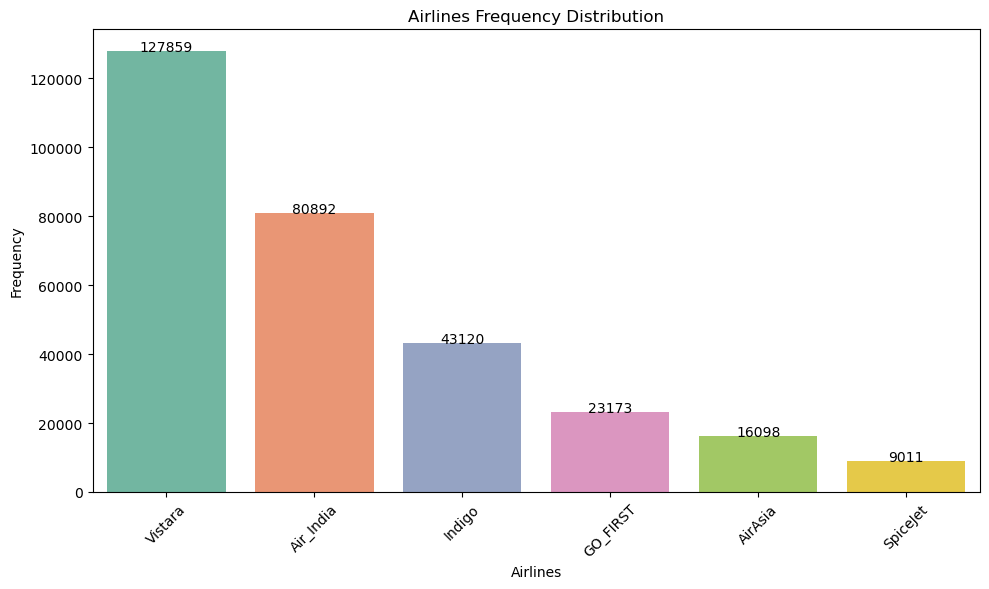

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count airlines
airlines_frequency = df['airline'].value_counts()

# Set style
plt.figure(figsize=(10, 6))

# Colorful palette
sns.barplot(
    x=airlines_frequency.index,
    y=airlines_frequency.values,
    palette='Set2'   # You can try: Set1, Set2, Set3, coolwarm, viridis
)

# Labels
plt.xlabel("Airlines")
plt.ylabel("Frequency")
plt.title("Airlines Frequency Distribution")

# Rotate labels
plt.xticks(rotation=45)

# Show values on bars
for i, v in enumerate(airlines_frequency.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

# Source city to destination city

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1344294203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.countplot(data=df,
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1344294203.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df,


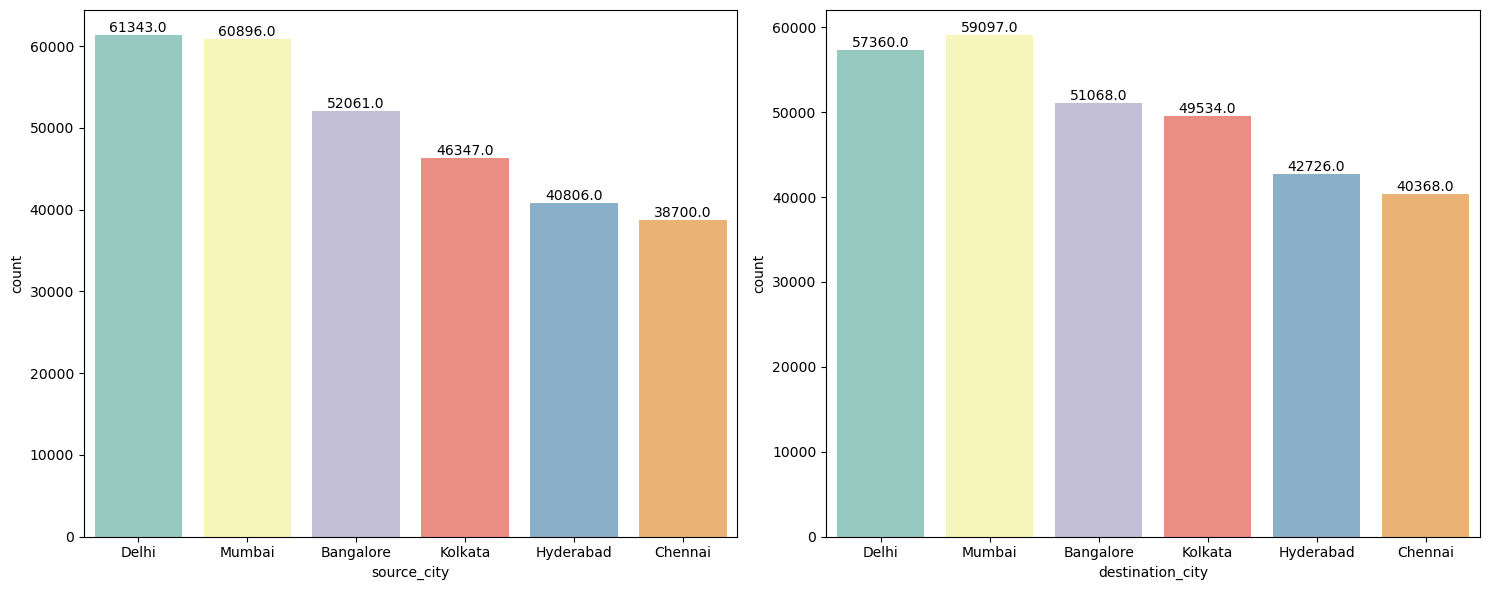

In [15]:
order = ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']

fig, axes = plt.subplots(1, 2, figsize=(15,6))

ax0 = sns.countplot(data=df,
              x='source_city',
              palette='Set3',
              order=order,
              ax=axes[0])
for p in ax0.patches:
    height = p.get_height()
    ax0.annotate(f"{height}",                
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10)

ax1 = sns.countplot(data=df,
              x='destination_city',
              palette='Set3',
              order=order,
              ax=axes[1])
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f"{height}",
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

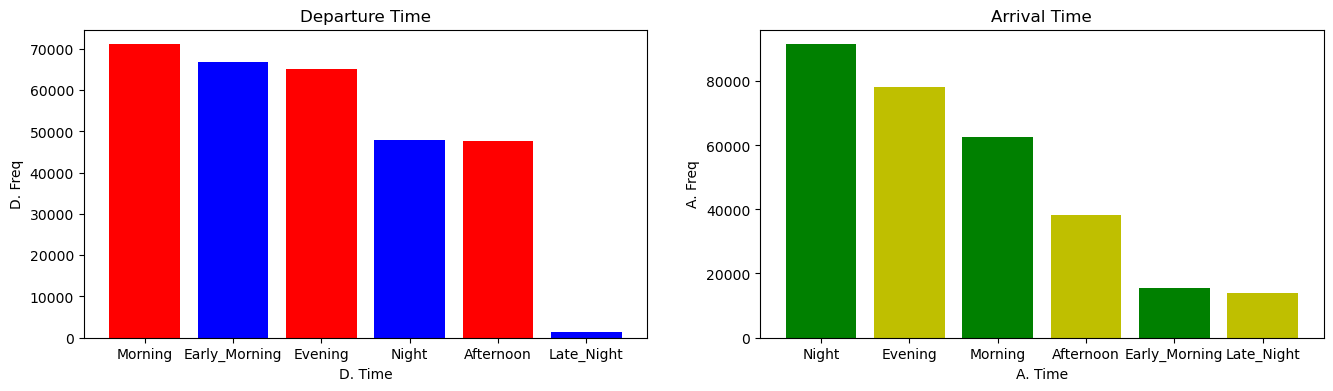

In [16]:
# ============================================================
# Cell 7: Univariate Analysis - Categorical Features
# ============================================================
# Showing the Departure Time & Arrival Time for the flights with their counts

plt.figure(figsize = (16,4))

plt.subplot(1,2,1)

plt.bar( df['departure_time'].value_counts().index , df['departure_time'].value_counts().values, color = ['r', 'b'] )
plt.title("Departure Time")
plt.xlabel("D. Time")
plt.ylabel("D. Freq")

plt.subplot(1,2,2)

plt.bar( df['arrival_time'].value_counts().index, df['arrival_time'].value_counts().values, color = ['g', 'y'])
plt.title("Arrival Time")
plt.xlabel("A. Time")
plt.ylabel("A. Freq")

plt.show()

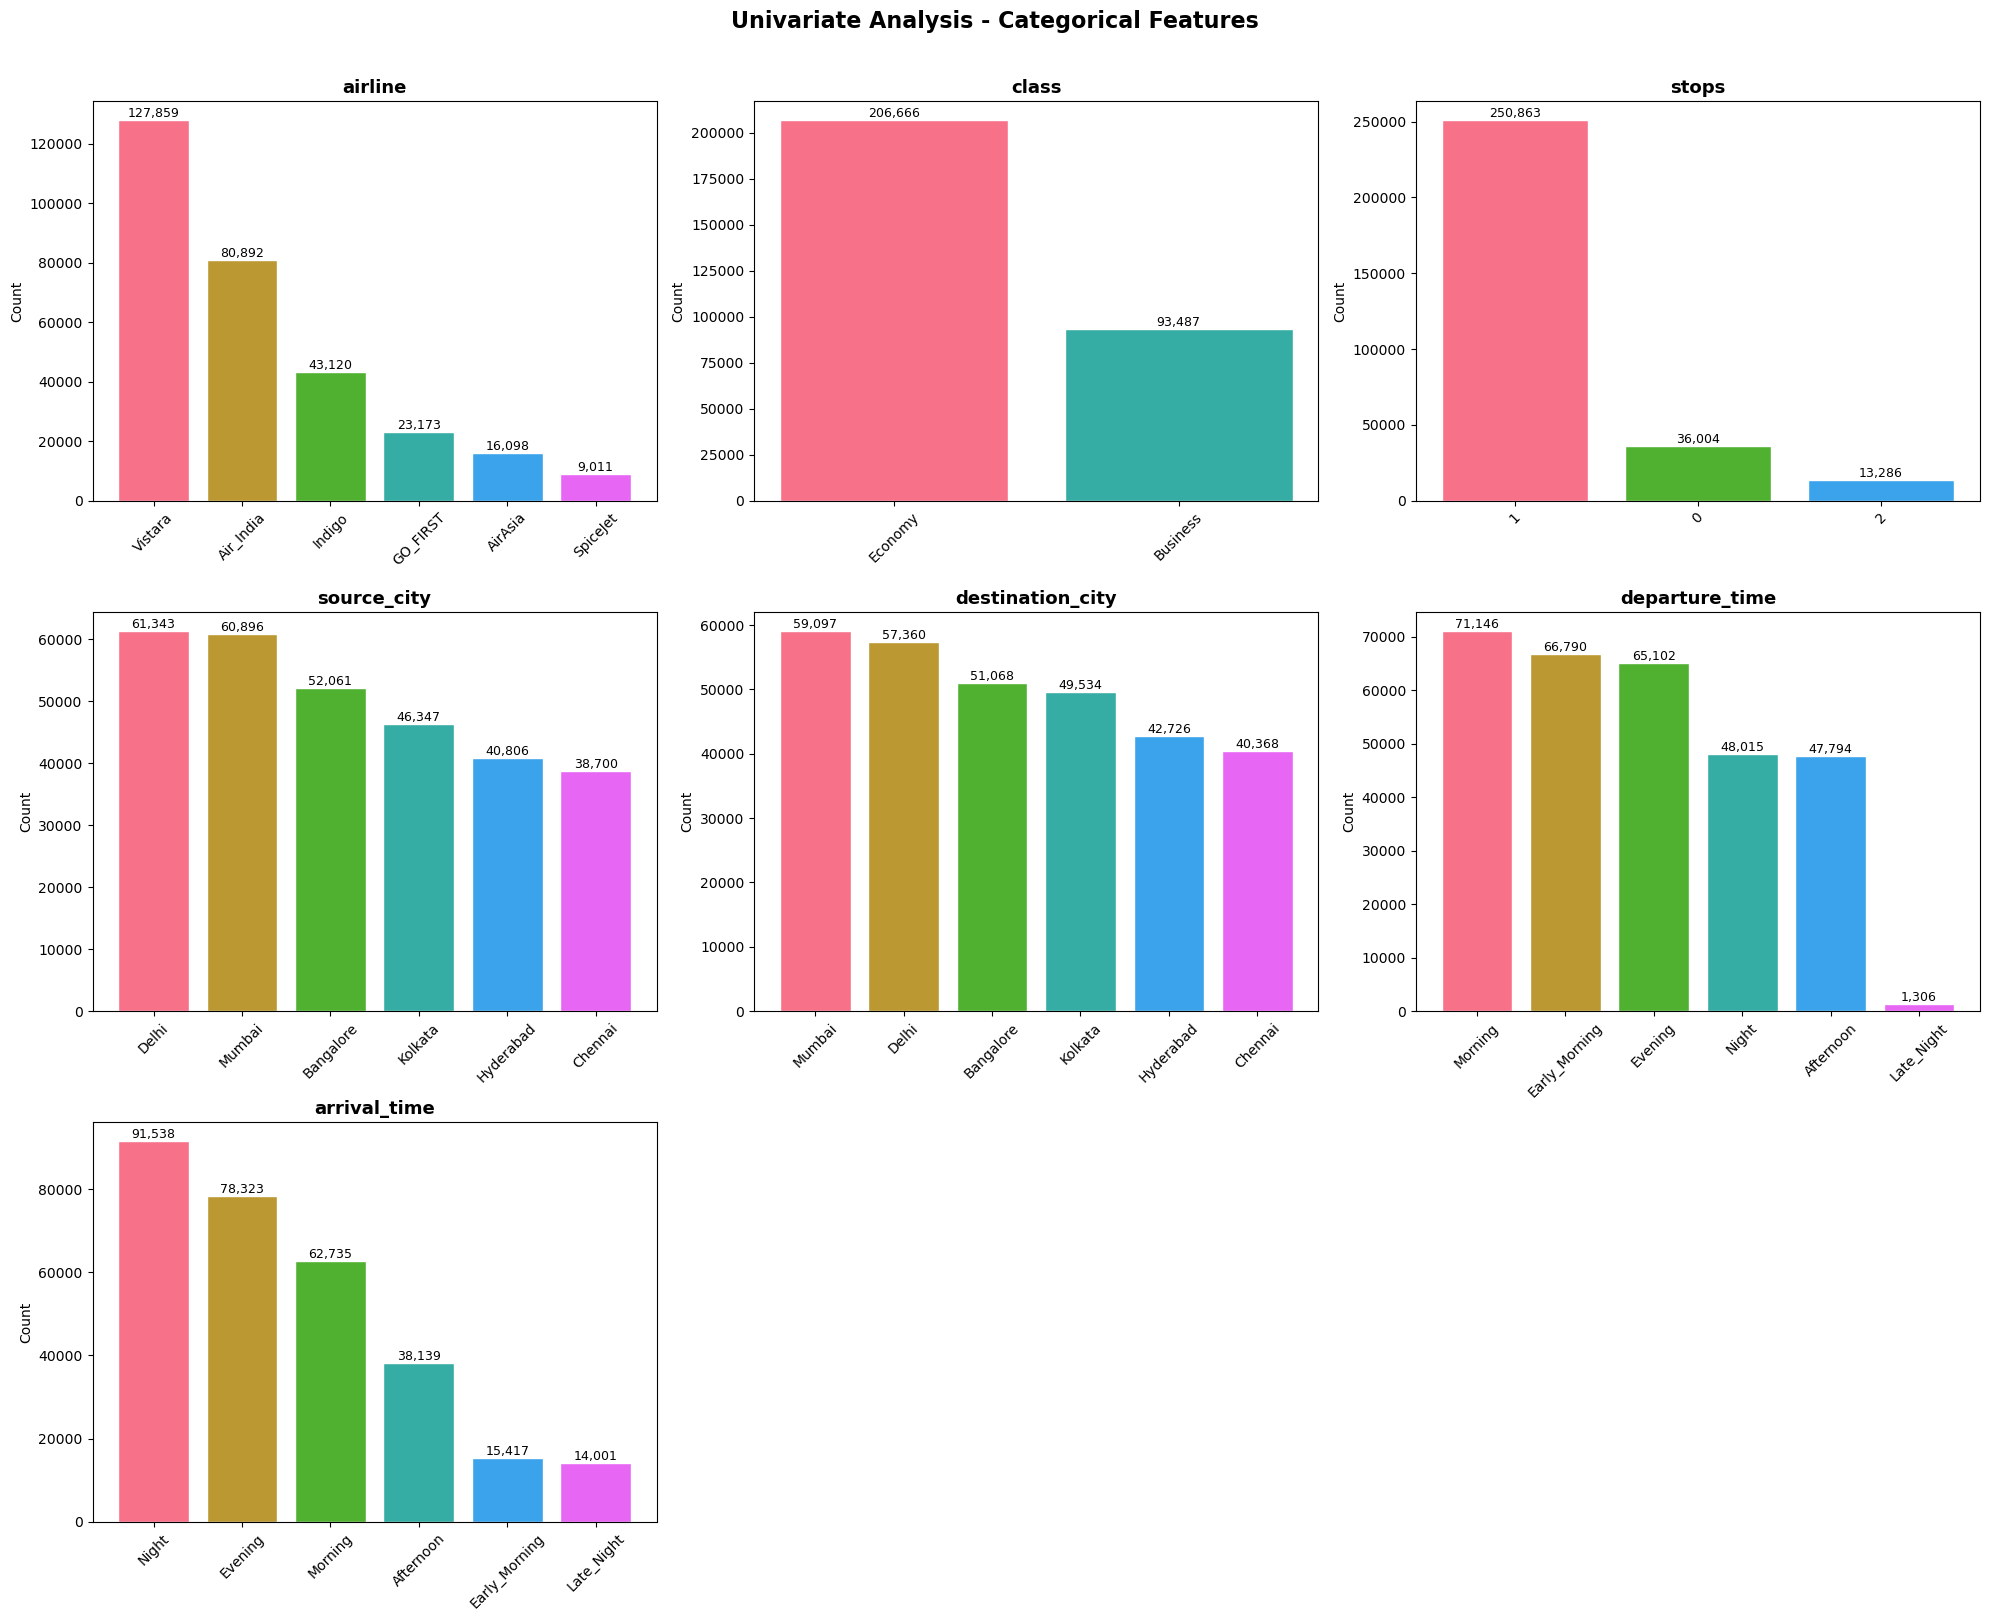

In [17]:
cat_to_plot = ['airline', 'class', 'stops', 'source_city',
               'destination_city', 'departure_time', 'arrival_time']

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                       color=sns.color_palette('husl', len(counts)), edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=13)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')
    
    # Add value labels
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h,
                     f'{h:,.0f}', ha='center', va='bottom', fontsize=9)

# Hide unused subplots
for j in range(len(cat_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis - Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1812422991.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='airline', y='price', ax=axes[0, 0], palette='husl')
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1812422991.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='price', ax=axes[0, 1], palette='Set2')
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1812422991.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stops', y='price', ax=axes[0, 2], palett

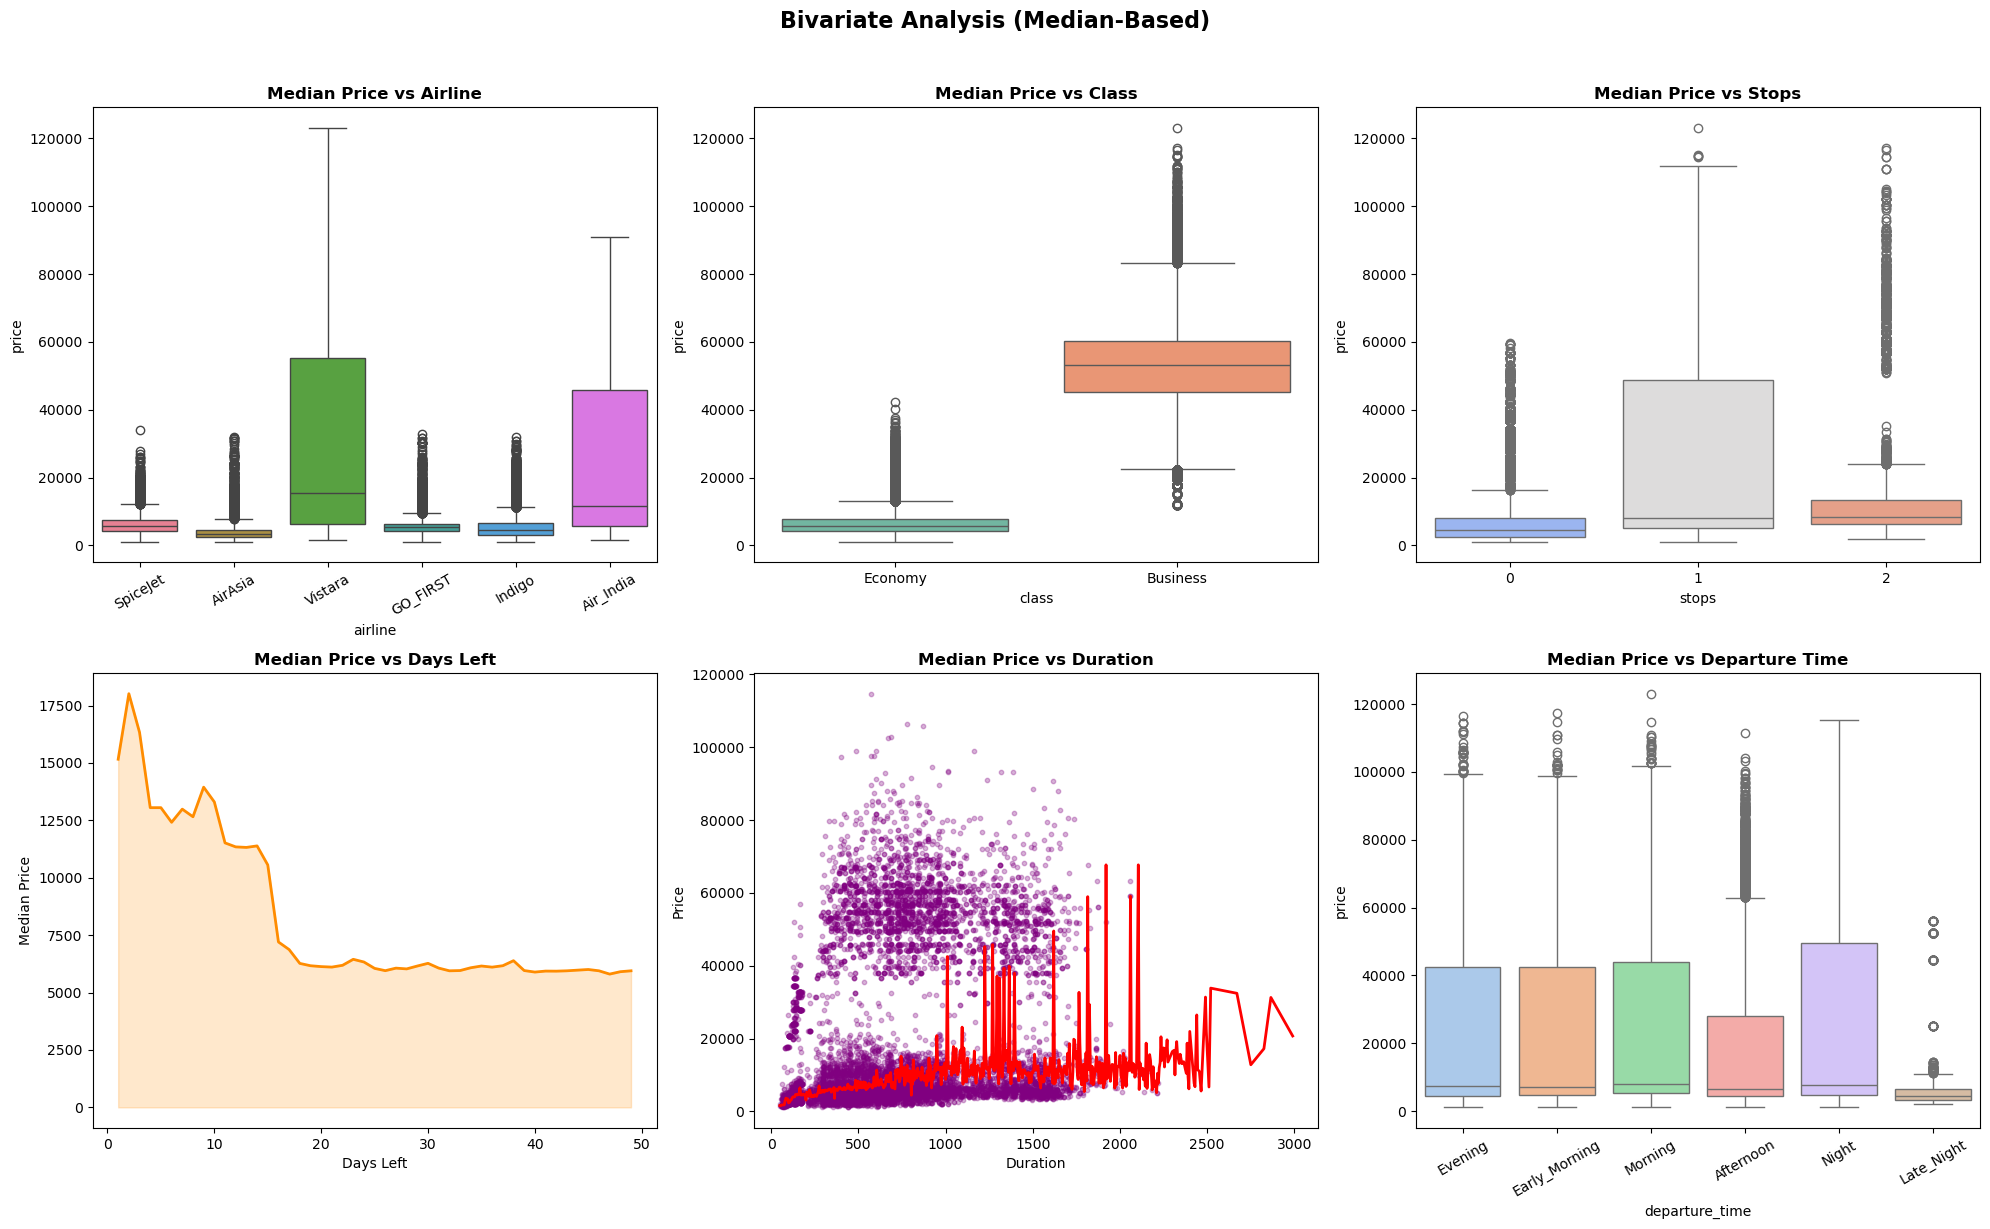

In [18]:
# ==============================================
# Bivariate Analysis (Median-Based)
# ==============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 12))


# 🔹 1. Price vs Airline (Boxplot → already median-based)
sns.boxplot(data=df, x='airline', y='price', ax=axes[0, 0], palette='husl')
axes[0, 0].set_title('Median Price vs Airline', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)


# 🔹 2. Price vs Class (Boxplot)
sns.boxplot(data=df, x='class', y='price', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Median Price vs Class', fontweight='bold')


# 🔹 3. Price vs Stops (Boxplot)
sns.boxplot(data=df, x='stops', y='price', ax=axes[0, 2], palette='coolwarm')
axes[0, 2].set_title('Median Price vs Stops', fontweight='bold')


# 🔹 4. Price vs Days Left (MEDIAN LINE)
median_price_days = df.groupby('days_left')['price'].median()

axes[1, 0].plot(median_price_days.index, median_price_days.values,
                color='darkorange', linewidth=2)
axes[1, 0].fill_between(median_price_days.index,
                        median_price_days.values,
                        alpha=0.2, color='darkorange')

axes[1, 0].set_title('Median Price vs Days Left', fontweight='bold')
axes[1, 0].set_xlabel('Days Left')
axes[1, 0].set_ylabel('Median Price')


# 🔹 5. Price vs Duration (Median Trend + Scatter)
sample = df.sample(n=10000, random_state=42)

axes[1, 1].scatter(sample['duration'], sample['price'],
                   alpha=0.3, s=10, color='purple')

# Median trend line
median_duration = df.groupby('duration')['price'].median()
axes[1, 1].plot(median_duration.index, median_duration.values,
                color='red', linewidth=2)

axes[1, 1].set_title('Median Price vs Duration', fontweight='bold')
axes[1, 1].set_xlabel('Duration')
axes[1, 1].set_ylabel('Price')


# 🔹 6. Price vs Departure Time (Boxplot)
sns.boxplot(data=df, x='departure_time', y='price',
            ax=axes[1, 2], palette='pastel')

axes[1, 2].set_title('Median Price vs Departure Time', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=30)


# ==============================================
# Final Layout
# ==============================================
plt.suptitle('Bivariate Analysis (Median-Based)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Pie charts

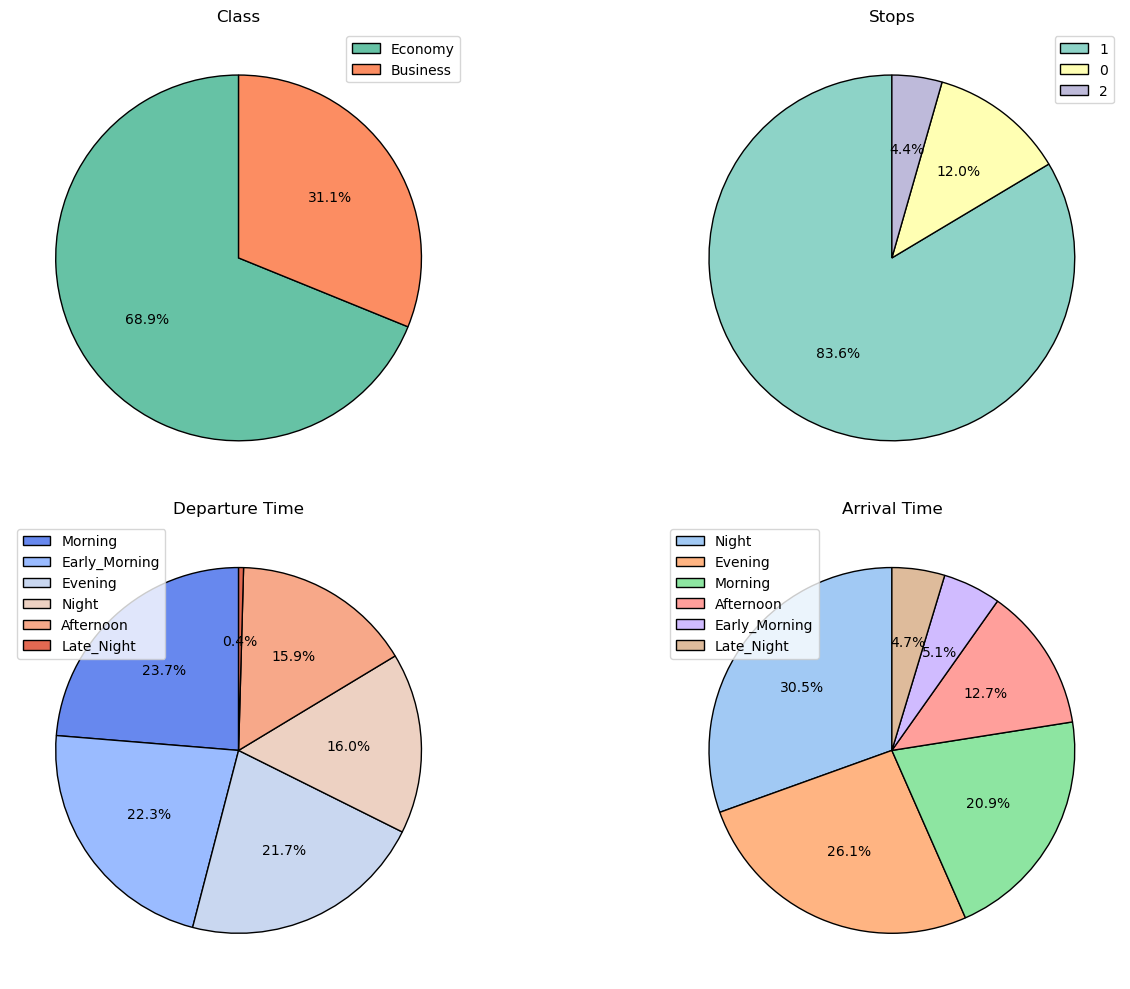

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Color palettes
colors1 = sns.color_palette("Set2")
colors2 = sns.color_palette("Set3")
colors3 = sns.color_palette("coolwarm")
colors4 = sns.color_palette("pastel")

# 🔹 Class
Class = df['class'].value_counts()
axs[0,0].pie(
    Class,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axs[0,0].set_title('Class')
axs[0,0].legend(Class.index, loc='best')

# 🔹 Stops
stops = df['stops'].value_counts()
axs[0,1].pie(
    stops,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axs[0,1].set_title('Stops')
axs[0,1].legend(stops.index, loc='best')

# 🔹 Departure Time
departure = df['departure_time'].value_counts()
axs[1,0].pie(
    departure,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors3,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axs[1,0].set_title('Departure Time')
axs[1,0].legend(departure.index, loc='best')

# 🔹 Arrival Time
arrival = df['arrival_time'].value_counts()
axs[1,1].pie(
    arrival,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors4,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axs[1,1].set_title('Arrival Time')
axs[1,1].legend(arrival.index, loc='best')

plt.tight_layout()
plt.show()

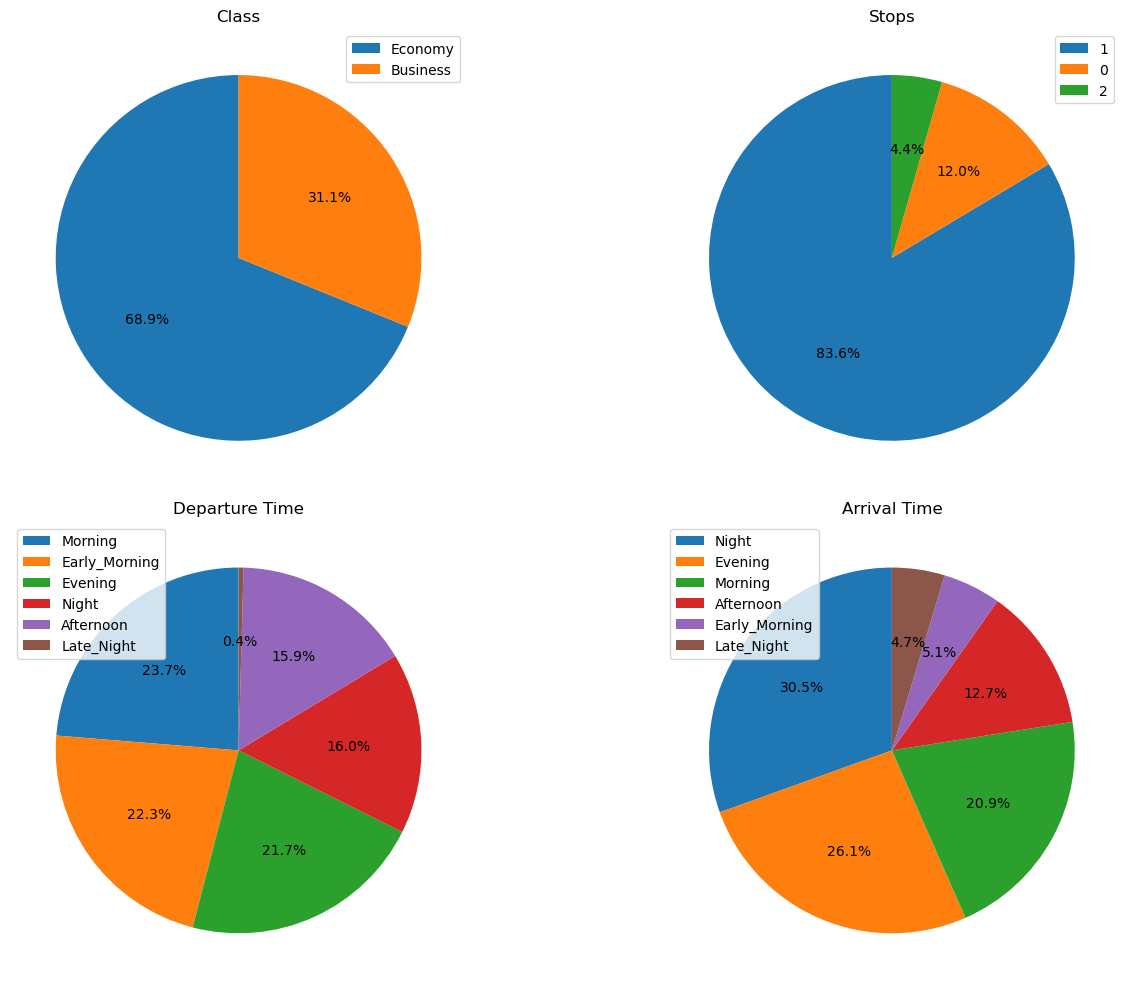

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 🔷 Class
Class = df['class'].value_counts()
axs[0,0].pie(Class, autopct='%1.1f%%', startangle=90)
axs[0,0].set_title('Class')
axs[0,0].legend(Class.index, loc='best')

# 🔷 Stops
stops = df['stops'].value_counts()
axs[0,1].pie(stops, autopct='%1.1f%%', startangle=90)
axs[0,1].set_title('Stops')
axs[0,1].legend(stops.index, loc='best')

# 🔷 Departure Time
departure = df['departure_time'].value_counts()
axs[1,0].pie(departure, autopct='%1.1f%%', startangle=90)
axs[1,0].set_title('Departure Time')
axs[1,0].legend(departure.index, loc='best')

# 🔷 Arrival Time
arrival = df['arrival_time'].value_counts()
axs[1,1].pie(arrival, autopct='%1.1f%%', startangle=90)
axs[1,1].set_title('Arrival Time')
axs[1,1].legend(arrival.index, loc='best')

plt.tight_layout()
plt.show()

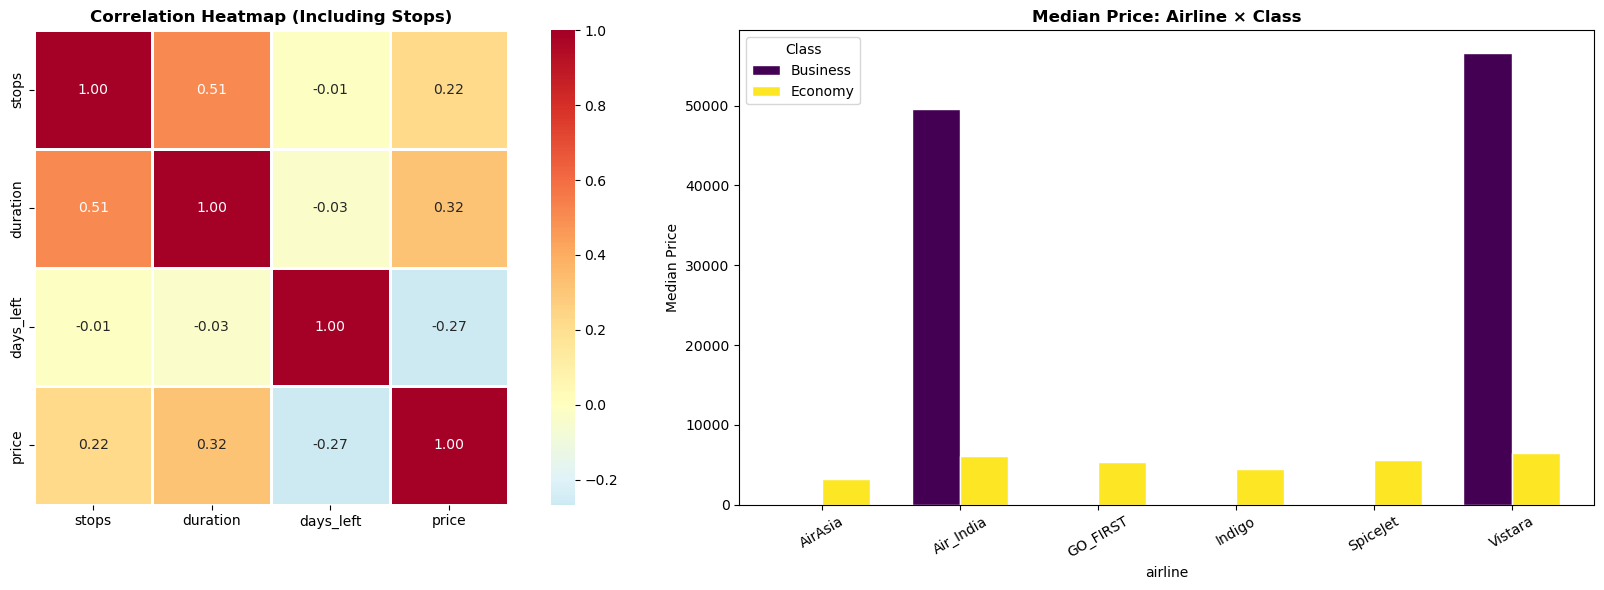

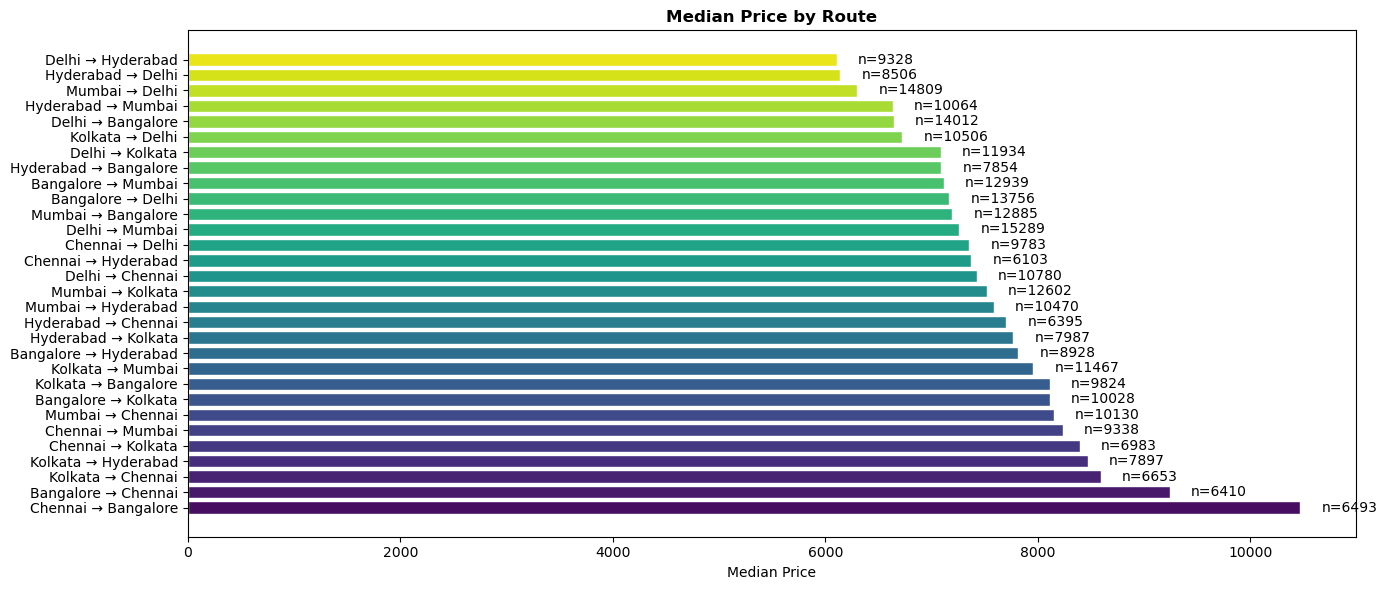

In [21]:
# ==============================================
# Cell 9: Multivariate Analysis (MEDIAN + STOPS)
# ==============================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# Step 1: Ensure 'stops' is numeric
# ==============================================
# If stops is categorical like "non-stop", convert it
if df['stops'].dtype == 'object':
    df['stops'] = df['stops'].astype('category').cat.codes


# ==============================================
# 9a. Correlation Heatmap (Include Stops)
# ==============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Select numeric columns including stops
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Spearman correlation (better for your data)
corr = df[numerical_cols].corr(method='spearman')

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu_r',   # more colorful 🔥
    center=0,
    fmt='.2f',
    square=True,
    linewidths=1,
    ax=axes[0]
)

axes[0].set_title('Correlation Heatmap (Including Stops)', fontweight='bold')


# ==============================================
# 9b. Median Price by Airline × Class
# ==============================================

pivot = df.pivot_table(
    values='price',
    index='airline',
    columns='class',
    aggfunc='median'
)

pivot.plot(
    kind='bar',
    ax=axes[1],
    edgecolor='white',
    width=0.7,
    colormap='viridis'
)

axes[1].set_title('Median Price: Airline × Class', fontweight='bold')
axes[1].set_ylabel('Median Price')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()


# ==============================================
# 9c. Top Routes by Median Price
# ==============================================

# Create route column
df['route'] = df['source_city'].astype(str) + " → " + df['destination_city'].astype(str)

# Median aggregation
route_price = df.groupby('route')['price'].agg(['median', 'count']).sort_values(by='median', ascending=False)

route_price.columns = ['median_price', 'flight_count']

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    route_price.index,
    route_price['median_price'],
    color=sns.color_palette('viridis', len(route_price)),
    edgecolor='white'
)

ax.set_xlabel('Median Price')
ax.set_title('Median Price by Route', fontweight='bold')

# Add count labels
for bar, count in zip(bars, route_price['flight_count']):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'n={count}',
            va='center')

plt.tight_layout()
plt.show()

# KS test 

In [22]:
# ==============================
# Step 3: Standardize the Data
# (Required for KS test with 'norm')
# ==============================
price_std = (df['price'] - df['price'].mean()) / df['price'].std()


# ==============================
# Step 4: Perform KS Test
# ==============================
ks_stat, p_value = stats.kstest(price_std, 'norm')


# ==============================
# Step 5: Print Results
# ==============================
print("===== Kolmogorov-Smirnov Test =====")
print("KS Statistic:", ks_stat)
print("p-value:", p_value)


# ==============================
# Step 6: Interpretation
# ==============================
alpha = 0.05

if p_value < alpha:
    print("\nConclusion: Data is NOT normally distributed")
else:
    print("\nConclusion: Data is normally distributed")

===== Kolmogorov-Smirnov Test =====
KS Statistic: 0.2781726047890952
p-value: 0.0

Conclusion: Data is NOT normally distributed


# Histogram

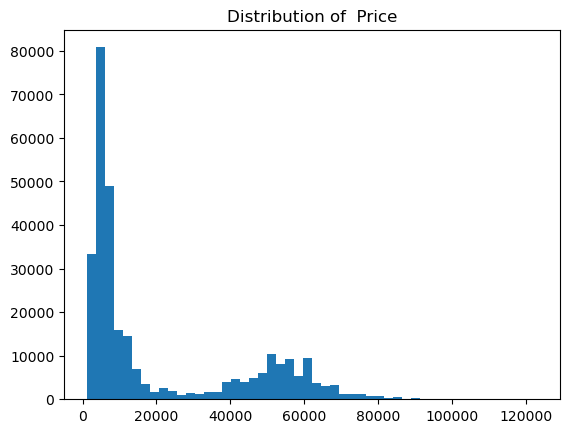

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['price'], bins=50)
plt.title("Distribution of  Price")
plt.show()

# interpretation:
The histogram shows that ticket prices are highly right-skewed, with most values concentrated at lower price ranges.
A large number of tickets fall below ₹20,000, while only a few have very high prices.
The long right tail indicates the presence of outliers (expensive tickets).

# Distribution of Price (Histogram)

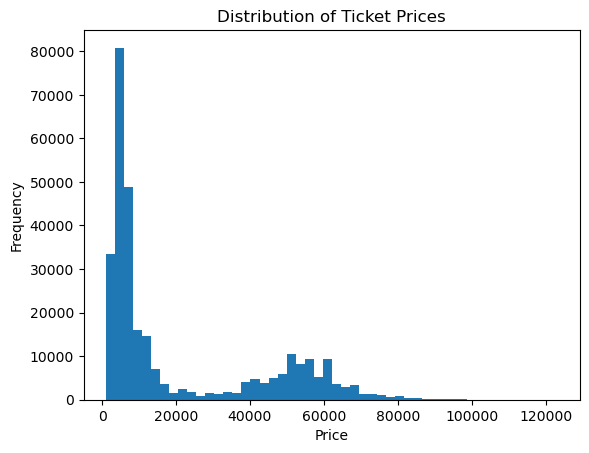

In [24]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.title("Distribution of Ticket Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Interpretation:
The distribution of ticket prices is highly right-skewed, with most tickets concentrated in the lower price range (below ₹20,000).
There is a noticeable second cluster around mid-range prices (₹40,000–₹60,000), indicating different pricing segments.
The long right tail shows the presence of high-priced outliers, which significantly increase the overall average price.

# Boxplot (Outlier Detection)

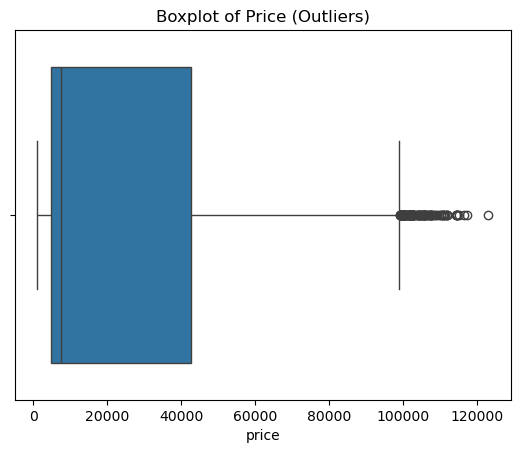

In [25]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price (Outliers)")
plt.show()

# interpretation:
The boxplot shows that ticket prices are positively skewed, with the median closer to the lower quartile.
Most prices lie within the lower range (compact box), while the upper whisker is long, indicating spread in higher values.
There are many points beyond the upper whisker, confirming the presence of significant high-price outliers.

# skewness and kurtosis


In [26]:
print("Skewness:", df['price'].skew())
print("Kurtosis:", df['price'].kurt())

Skewness: 1.0613772532064343
Kurtosis: -0.3962927186960772


# Interpretation:
The skewness value of 1.06 indicates that the price distribution is positively (right) skewed, meaning most ticket prices are low, with a few very high values.
The kurtosis value of -0.39 suggests a platykurtic distribution, meaning it is slightly flatter than a normal distribution with fewer extreme peaks.
Overall, the data shows right skewness with moderate spread and some outliers, but not extremely heavy tails.

# count plot

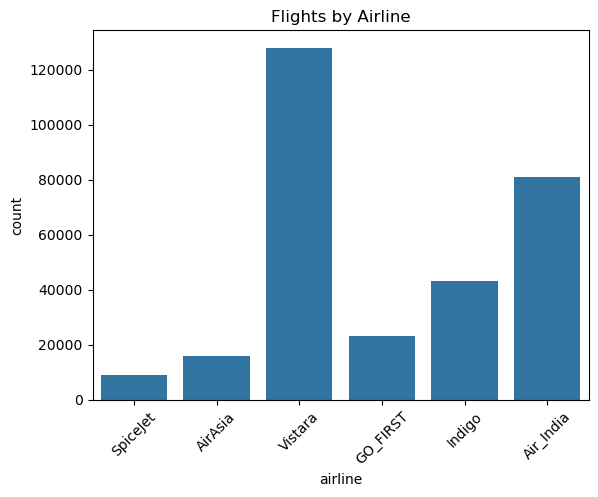

In [27]:
sns.countplot(x='airline', data=df)
plt.xticks(rotation=45)
plt.title("Flights by Airline")
plt.show()

# Interpretation:
The count plot shows that Vistara has the highest number of flights, followed by Air India and Indigo, indicating their strong presence in the dataset.
Airlines like GO FIRST, AirAsia, and SpiceJet have comparatively fewer flights.
Overall, the distribution is imbalanced, with a few airlines dominating the majority of flight records.

# Price vs Airline

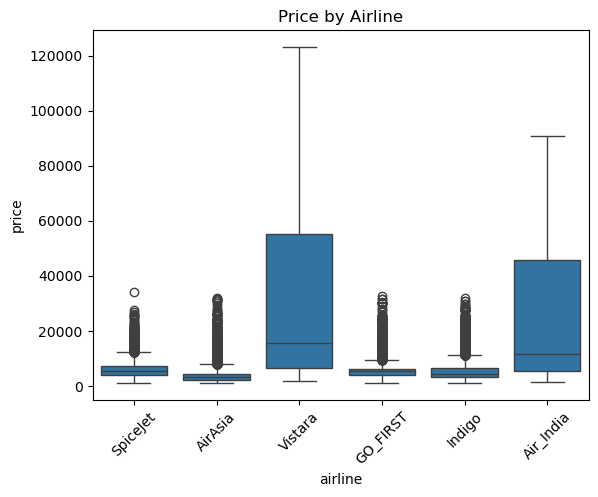

In [28]:
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Airline")
plt.show()

# interpretation:
The boxplot shows that Vistara and Air India have higher median ticket prices and a wider spread, indicating more expensive and variable pricing.
Airlines like AirAsia, SpiceJet, and GO FIRST have lower median prices, suggesting they are more budget-friendly.
There are many outliers across all airlines, especially at higher price levels, showing occasional expensive tickets.
Overall, ticket pricing varies significantly by airline, with premium airlines charging higher fares.

 # Price vs Stops

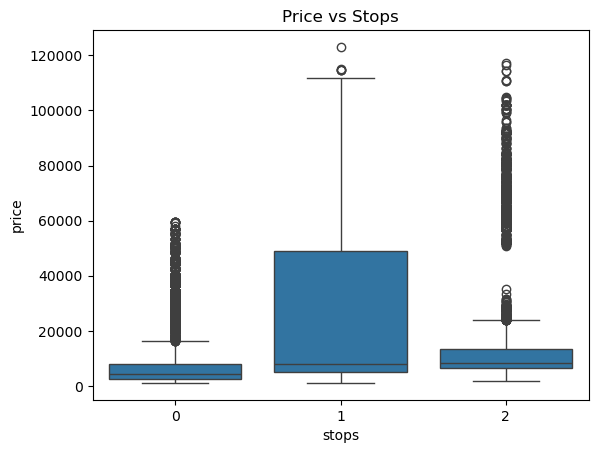

In [29]:
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price vs Stops")
plt.show()

# interpretation
The boxplot shows that flights with 1 stop tend to have higher and more variable prices compared to non-stop and 2-stop flights.
Non-stop flights (0 stops) generally have lower median prices, but still show some high-price outliers.
Flights with 2 stops have moderate prices but also include several high-value outliers.
Overall, ticket price does not increase strictly with stops, but 1-stop flights appear to be the most expensive on average.

# Price vs Class

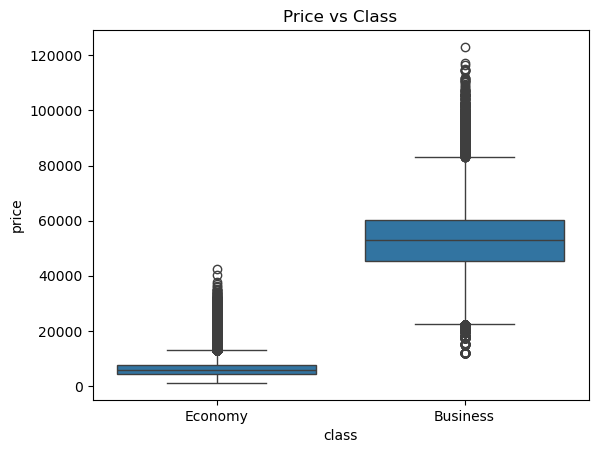

In [30]:
sns.boxplot(x='class', y='price', data=df)
plt.title("Price vs Class")
plt.show()

# Interpretation:
The boxplot clearly shows that Business class tickets are significantly more expensive than Economy class tickets.
Business class has a much higher median price and wider spread, indicating greater variability in pricing.
Economy class prices are relatively low and more concentrated, though a few high-price outliers exist.
Overall, ticket class is a major factor influencing price, with Business class consistently costing more.

#  Scatter Plot (Duration vs Price)

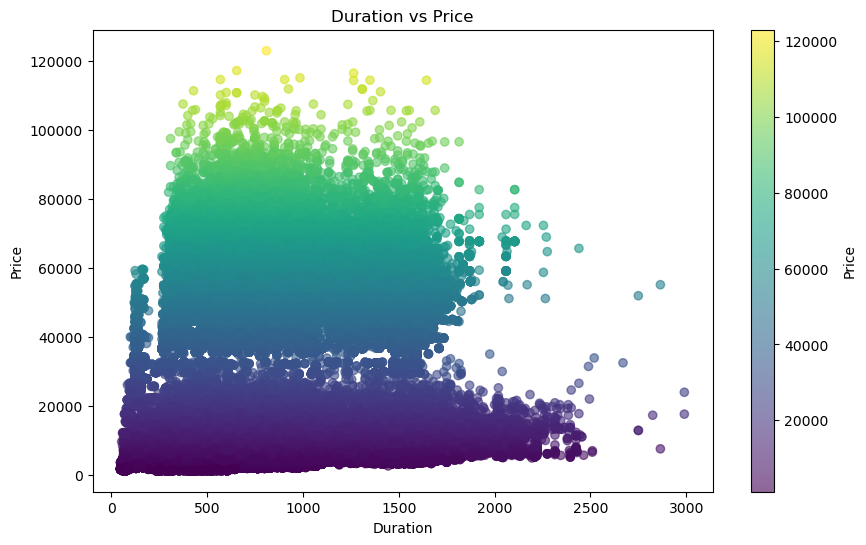

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Color based on price (gradient)
scatter = plt.scatter(
    df['duration'],
    df['price'],
    c=df['price'],           # color by price
    cmap='viridis',          # try: plasma, coolwarm, turbo
    alpha=0.6
)

# Color bar
plt.colorbar(scatter, label='Price')

# Labels
plt.xlabel("Duration")
plt.ylabel("Price")
plt.title("Duration vs Price")

plt.show()

# interpretation:
The scatter plot shows a weak positive relationship between duration and price, meaning longer flights tend to have higher prices.
However, the points are widely scattered, indicating that duration alone does not strongly determine price.
There is high variability in prices for similar durations, along with some outliers at both low and high values.
Overall, other factors (like airline, class, and stops) also significantly influence ticket prices.

# Scatter Plot (Days Left vs Price)

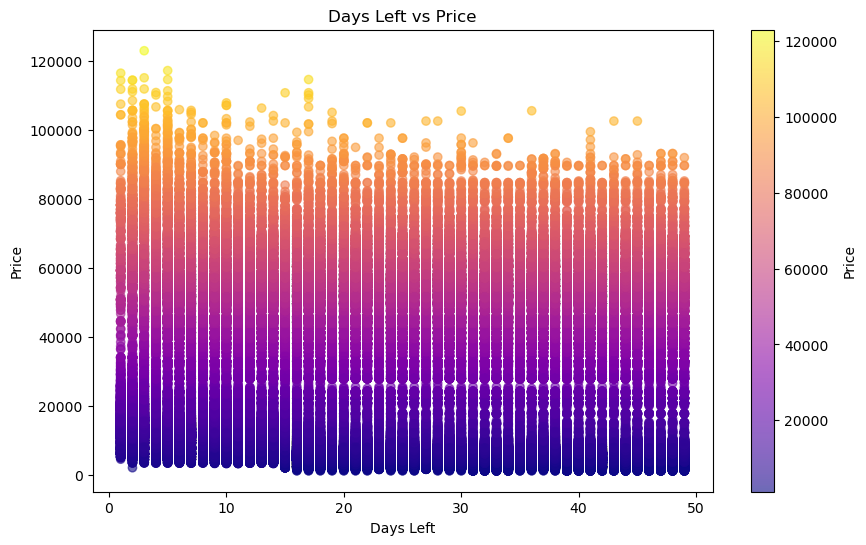

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Color based on price
scatter = plt.scatter(
    df['days_left'],
    df['price'],
    c=df['price'],        # color gradient
    cmap='plasma',        # try: viridis, coolwarm, turbo
    alpha=0.6
)

# Color bar
plt.colorbar(scatter, label='Price')

# Labels
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.title("Days Left vs Price")

plt.show()

# interpretation:
The scatter plot shows a weak negative relationship between days left and price, meaning prices tend to be higher when booking closer to departure.
However, the points are highly scattered, indicating that days left alone is not a strong predictor of price.
There is significant variability in prices across all booking days, with many outliers.
Overall, while early booking may slightly reduce prices, other factors also strongly influence ticket cost.

# Pairplot (Important Variables)

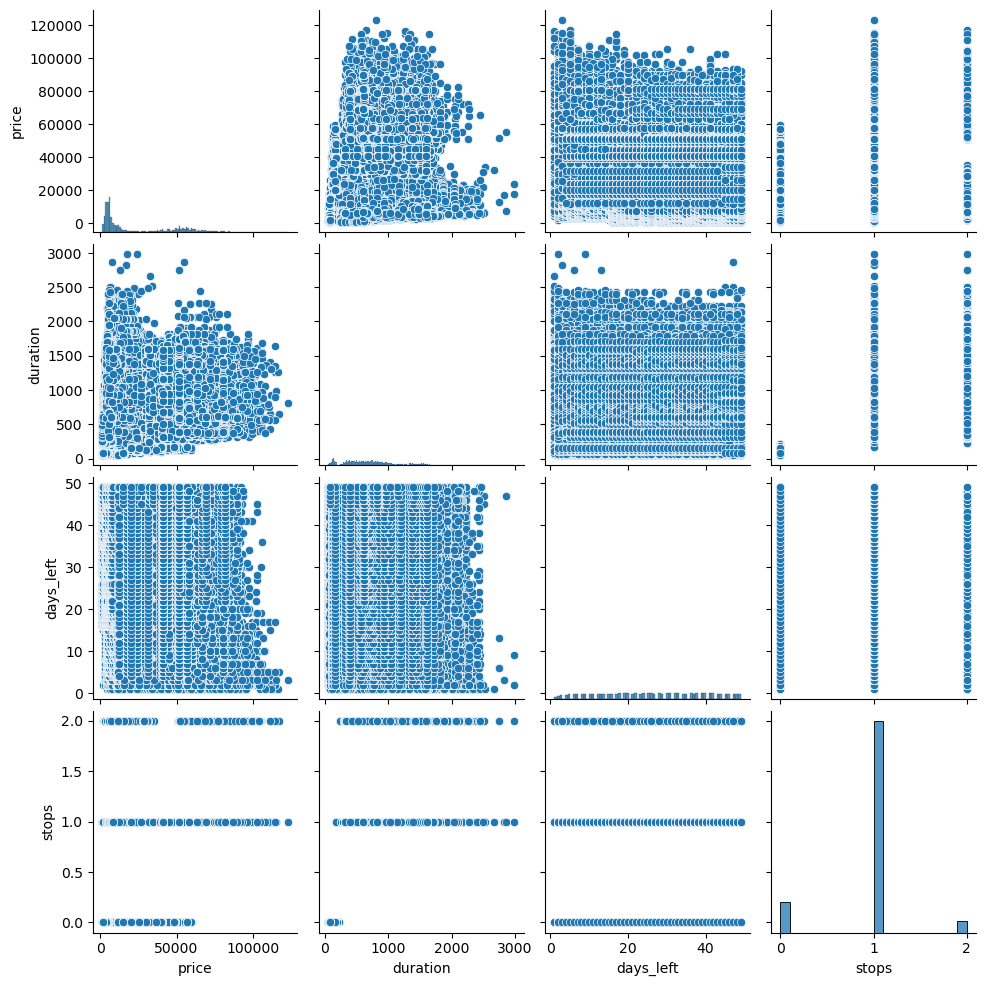

In [33]:
sns.pairplot(df[['price', 'duration', 'days_left', 'stops']])
plt.show()

# Violin Plot (Class vs Price)

# Interpretation: 
The violin plot shows that Business class prices are much higher and more widely distributed compared to Economy class.
Economy class prices are concentrated in a lower range with less variability, indicating more consistent pricing.
Business class has a broader spread and longer tails, showing greater variation and more high-price values.
Overall, the distribution clearly highlights that class significantly affects ticket pricing, with Business class being more expensive.

# Route-wise Analysis

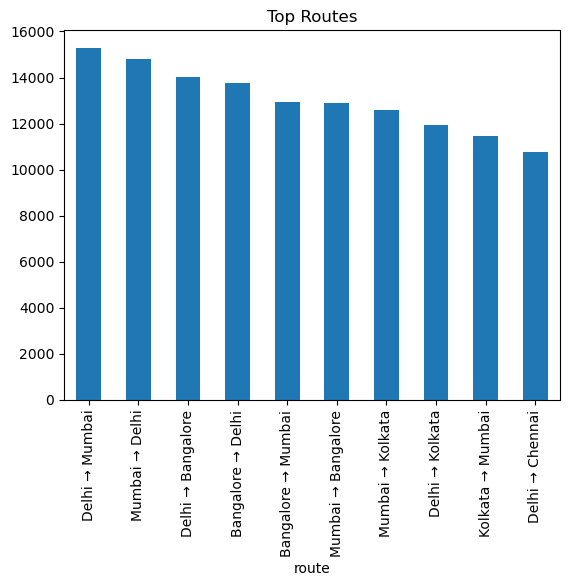

In [34]:
df['route'] = df['source_city'] + " → " + df['destination_city']

top_routes = df['route'].value_counts().head(10)

top_routes.plot(kind='bar')
plt.title("Top Routes")
plt.show()

# interpretation:
The bar chart shows that Delhi → Mumbai is the most frequent route, followed by Mumbai → Delhi and Delhi → Bangalore.
Major metro routes like Delhi, Mumbai, Bangalore, and Kolkata dominate the top routes, indicating high travel demand between these cities.
The counts are relatively close, suggesting consistent traffic across major routes rather than one route dominating excessively.
Overall, the analysis highlights that metro city connections have the highest flight frequency and demand.

# Departure Time vs Price

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\4036548919.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\4036548919.py:13: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  ax = sns.boxplot(


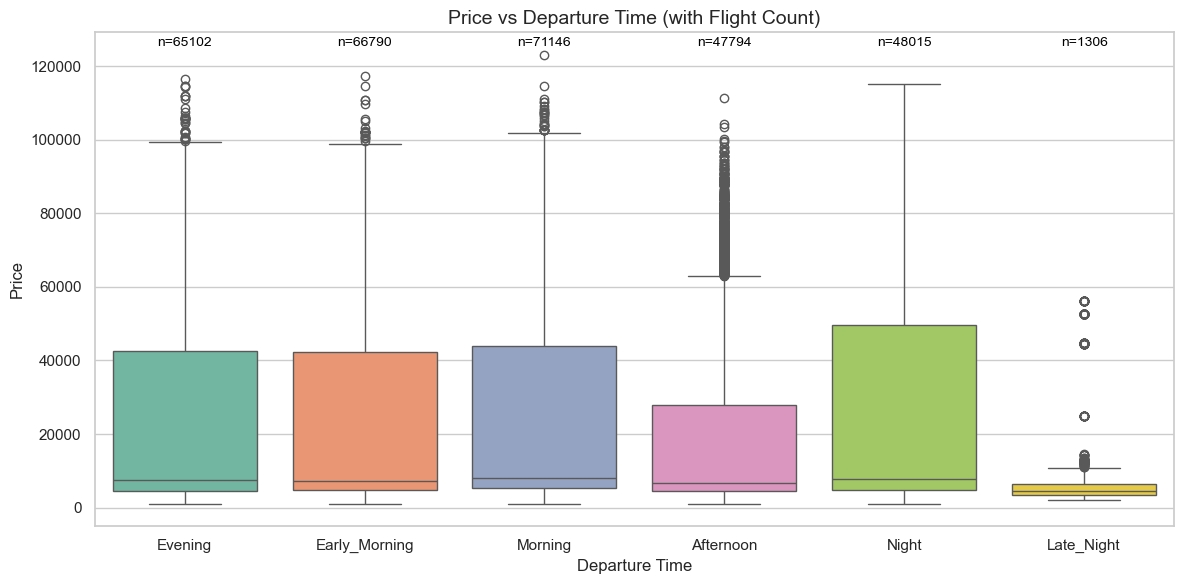

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# Colorful palette
palette = sns.color_palette("Set2")

# Boxplot
ax = sns.boxplot(
    x='departure_time',
    y='price',
    data=df,
    palette=palette
)

# Title & labels
plt.title("Price vs Departure Time (with Flight Count)", fontsize=14)
plt.xlabel("Departure Time")
plt.ylabel("Price")

# 🔥 Add flight counts on top
counts = df['departure_time'].value_counts()

for i, category in enumerate(ax.get_xticklabels()):
    cat = category.get_text()
    count = counts[cat]
    
    # position above box
    ax.text(i, df['price'].max()*1.02, f'n={count}', 
            ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# interpretation:
The boxplot shows that Night and Morning flights tend to have higher median prices and wider variability, indicating they are often more expensive.
Afternoon and Late Night flights generally have lower prices, making them more budget-friendly options.
There are many outliers across all time slots, especially for Evening and Morning flights, showing occasional high-priced tickets.
Overall, departure time influences price, but the variation suggests other factors also play an important role.

# heatmap

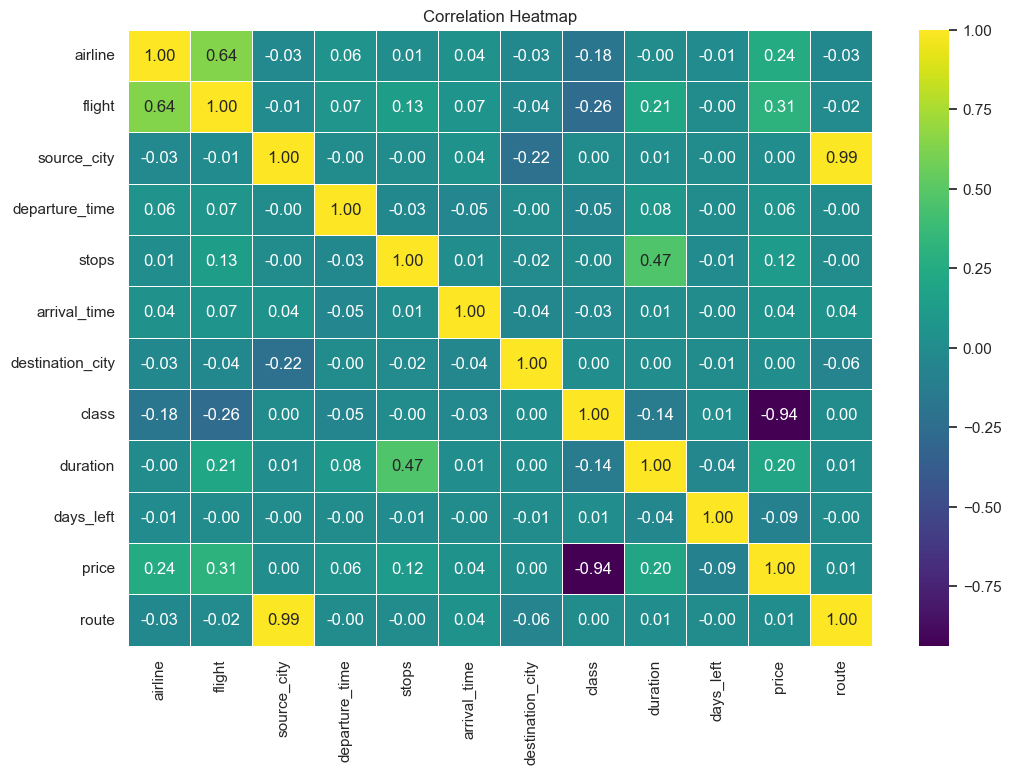

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert categorical columns to numeric (important)
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Compute correlation matrix
corr = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,        # show values
    cmap='viridis',   # color theme
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Source City Count (Colorful Bar Chart)

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\4058818013.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


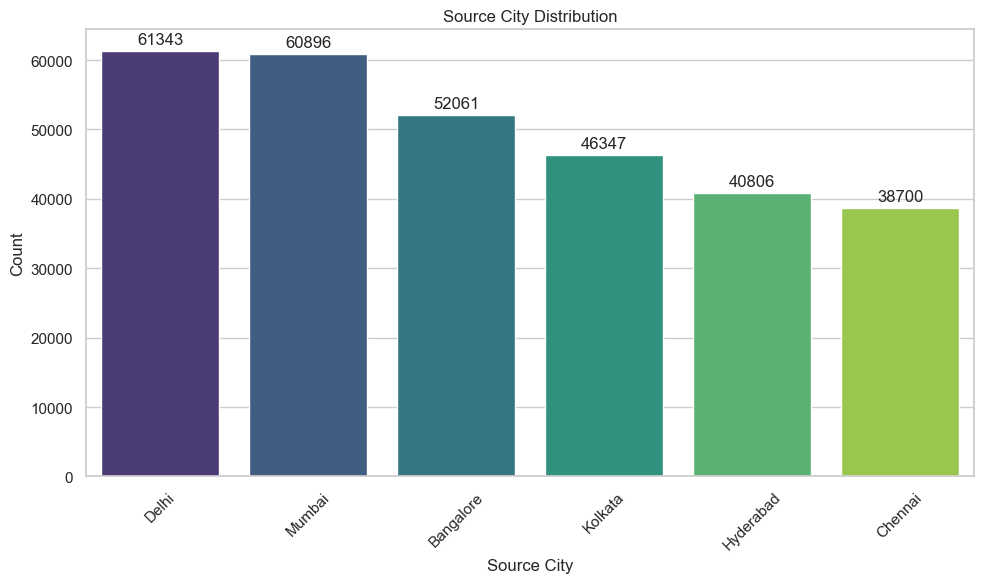

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count source cities
source_counts = df['source_city'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=source_counts.index,
    y=source_counts.values,
    palette='viridis'
)

# Add values on top
for i, v in enumerate(source_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')

plt.title("Source City Distribution")
plt.xlabel("Source City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Destination City Count (Colorful Bar Chart)

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\4097429967.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


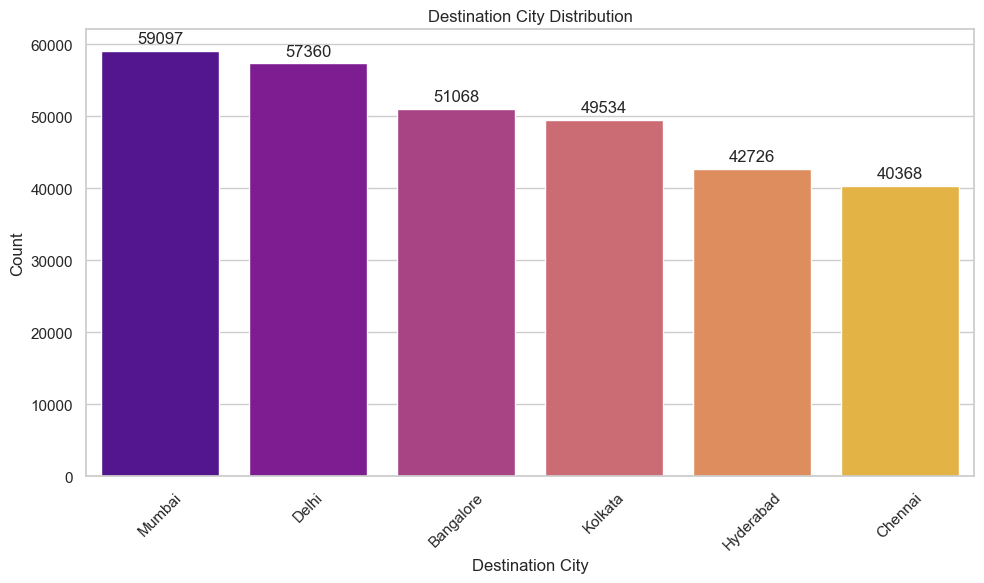

In [38]:
# Count destination cities
destination_counts = df['destination_city'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=destination_counts.index,
    y=destination_counts.values,
    palette='plasma'
)

# Add values on top
for i, v in enumerate(destination_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')

plt.title("Destination City Distribution")
plt.xlabel("Destination City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

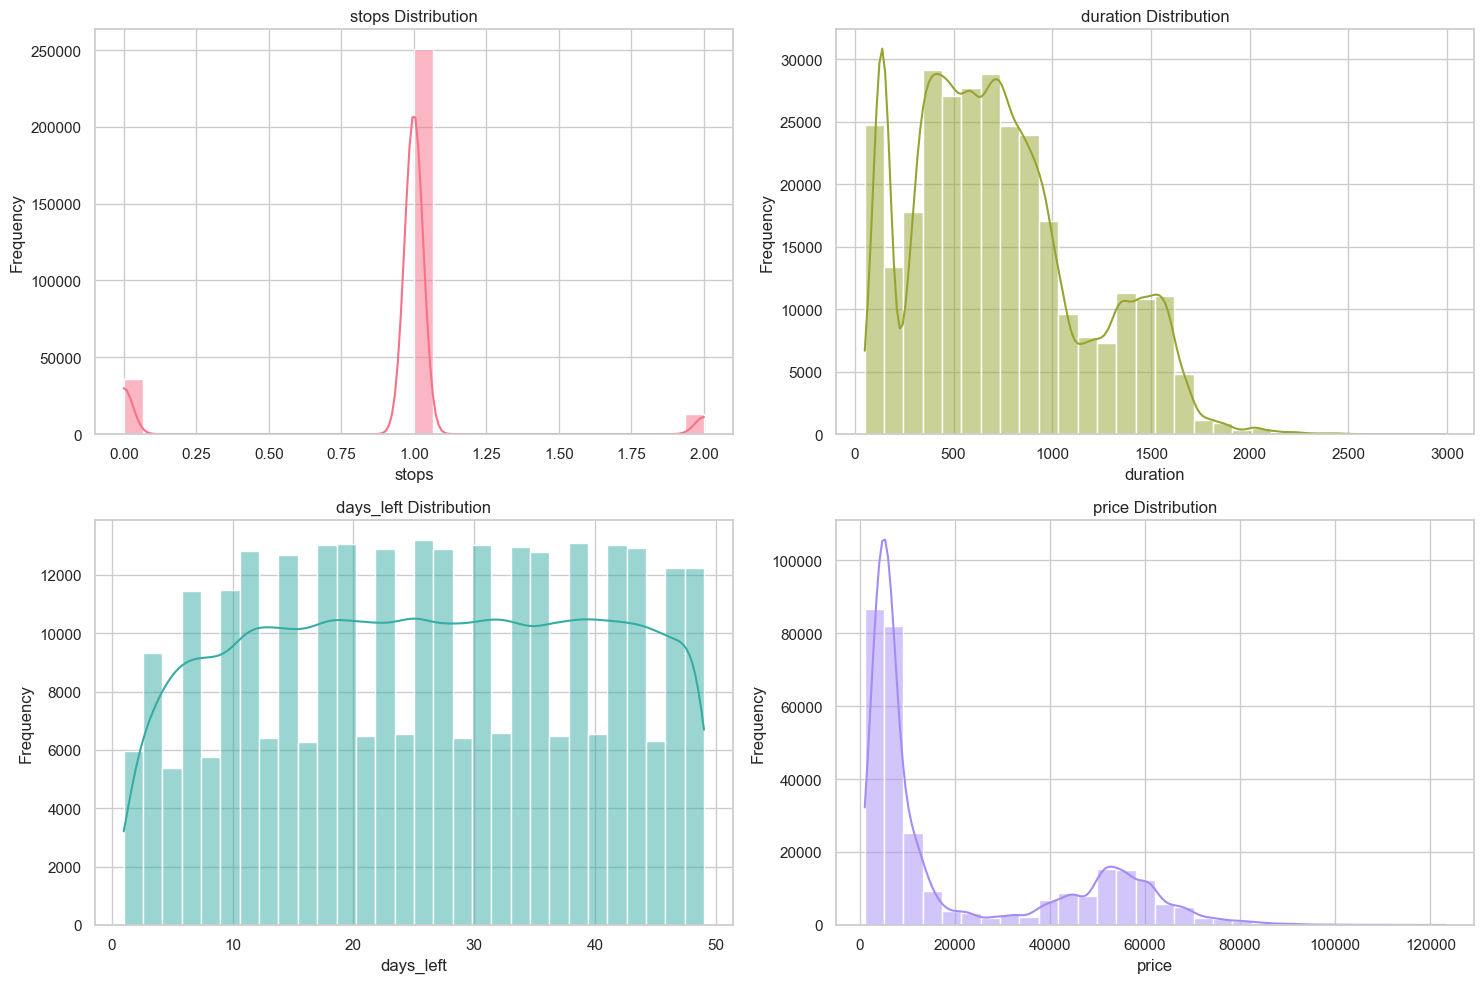

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set style
sns.set(style="whitegrid")

# Create subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)   # adjust if more variables
    
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=sns.color_palette("husl", len(num_cols))[i-1]
    )
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# top ten routes

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\2973446519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


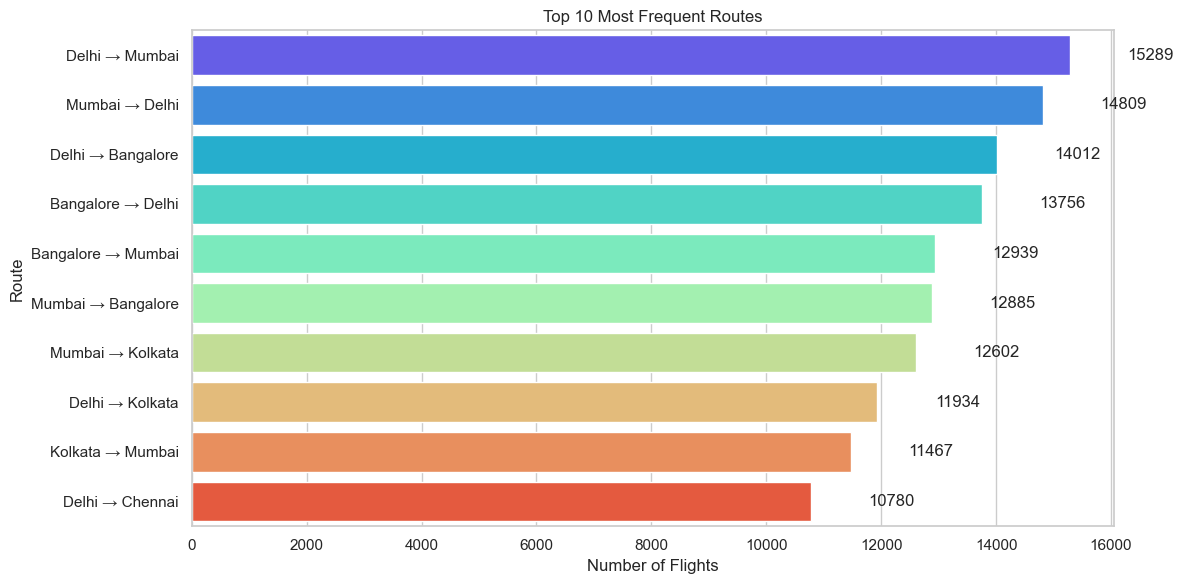

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create route column (if not already created)
df['route'] = df['source_city'] + " → " + df['destination_city']

# Get top 10 routes
top_routes = df['route'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_routes.values,
    y=top_routes.index,
    palette='rainbow'
)

# Add values
for i, v in enumerate(top_routes.values):
    plt.text(v + 1000, i, str(v), va='center')

plt.title("Top 10 Most Frequent Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

# 2.To analyze the impact of key factors such as airline, class and  route on ticket prices.

# Airline Wise

In [41]:
airline_stats = df.groupby('airline')['price'].agg(['median', 'mean', 'min', 'max'])
print(airline_stats.sort_values(by='median', ascending=False))

            median          mean   min     max
airline                                       
Vistara    15543.0  30396.536302  1714  123071
Air_India  11520.0  23507.019112  1526   90970
SpiceJet    5654.0   6179.278881  1106   34158
GO_FIRST    5336.0   5652.007595  1105   32803
Indigo      4453.0   5324.216303  1105   31952
AirAsia     3276.0   4091.072742  1105   31917


# class wise

In [42]:

class_stats = df.groupby('class')['price'].agg(['median', 'mean', 'min', 'max'])
print(class_stats)

           median          mean    min     max
class                                         
Business  53164.0  52540.081124  12000  123071
Economy    5772.0   6572.342383   1105   42349


 # Route Wise

In [43]:
route_stats = df.groupby('route')['price'].agg(['median', 'mean', 'count'])
print(route_stats.sort_values(by='median', ascending=False).head(10))

                      median          mean  count
route                                            
Chennai → Bangalore  10469.0  25081.850454   6493
Bangalore → Chennai   9241.0  23321.850078   6410
Kolkata → Chennai     8589.0  23660.361040   6653
Kolkata → Hyderabad   8467.0  21500.011397   7897
Chennai → Kolkata     8394.0  22669.932407   6983
Chennai → Mumbai      8233.0  22765.849647   9338
Mumbai → Chennai      8148.0  22781.899112  10130
Bangalore → Kolkata   8112.0  23500.061229  10028
Kolkata → Bangalore   8111.0  22744.808428   9824
Kolkata → Mumbai      7958.0  22078.883579  11467


# Price by Airline

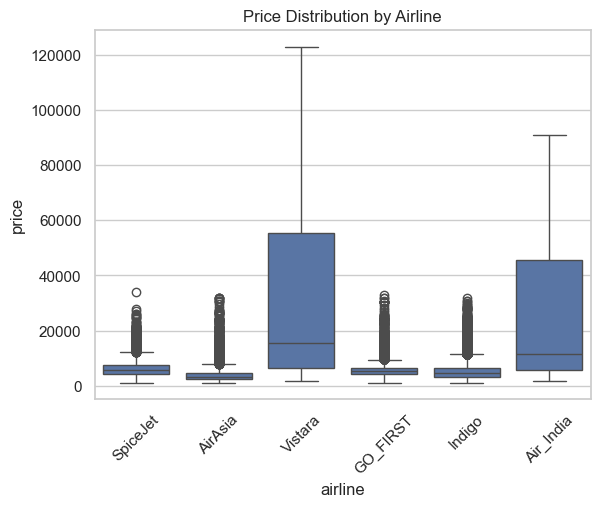

In [44]:
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Airline")
plt.show()

# interpretation:
The boxplot shows that Vistara and Air India have higher median prices and a wider price range, indicating premium pricing and greater variability.
Budget airlines like AirAsia, SpiceJet, and GO FIRST have lower median prices with more concentrated distributions.
There are numerous outliers across all airlines, especially at higher price levels, reflecting occasional expensive tickets.
Overall, airline choice significantly impacts ticket price, with full-service airlines generally being more expensive than low-cost carriers.

# Price by class

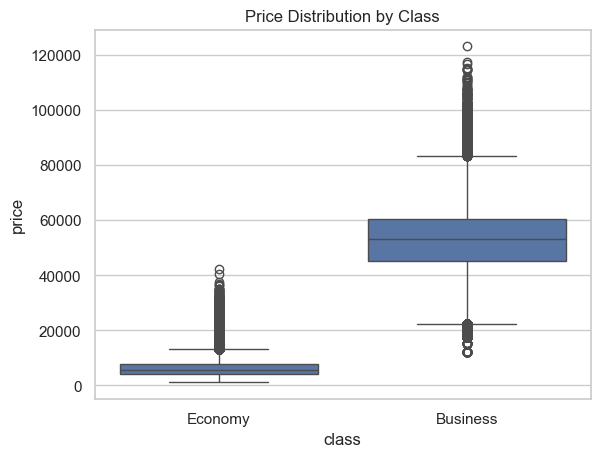

In [45]:
sns.boxplot(x='class', y='price', data=df)
plt.title("Price Distribution by Class")
plt.show()

# interpretation:
The boxplot shows that Business class fares are significantly higher than Economy class, with a much higher median price.
Business class also has a wider spread, indicating greater variability in ticket prices.
Economy class prices are lower and more concentrated, though some high-price outliers exist.
Overall, class is a strong determinant of ticket price, with Business class consistently more expensive.

# Price by Route (Top 10)

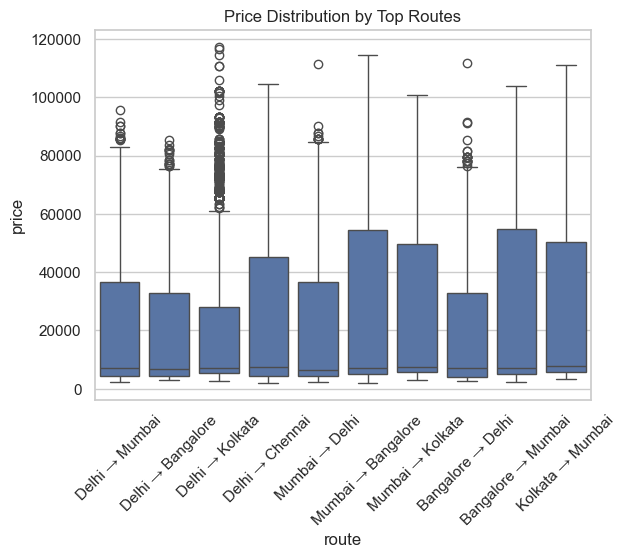

In [46]:
top_routes = df['route'].value_counts().head(10).index

sns.boxplot(x='route', y='price', data=df[df['route'].isin(top_routes)])
plt.xticks(rotation=45)
plt.title("Price Distribution by Top Routes")
plt.show()

# interpretation: 
The boxplot shows that ticket prices vary significantly across different routes, with some routes having higher median prices and wider spreads.
Routes like Mumbai–Bangalore and Bangalore–Delhi tend to have higher price ranges, indicating greater demand or longer distances.
Most routes have a right-skewed distribution, with many high-price outliers present.
Overall, route plays an important role in determining ticket price, with major metro routes showing higher variability and cost.

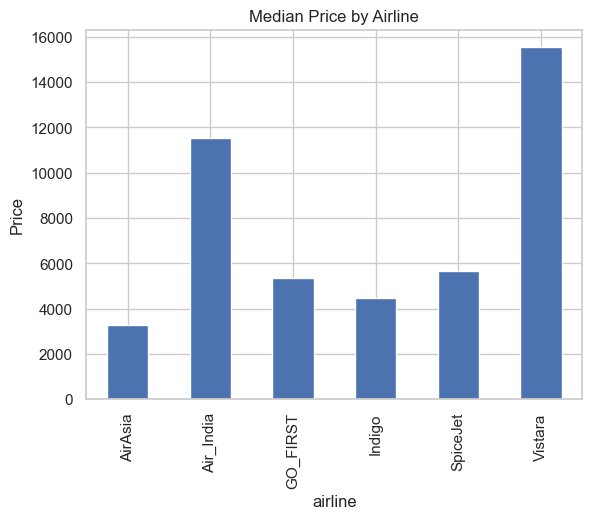

In [47]:
median_airline = df.groupby('airline')['price'].median()

median_airline.plot(kind='bar')
plt.title("Median Price by Airline")
plt.ylabel("Price")
plt.show()

# interpretation:
The bar chart shows that Vistara has the highest median ticket price, followed by Air India, indicating they are premium airlines.
Budget airlines like AirAsia, Indigo, SpiceJet, and GO FIRST have significantly lower median prices.
AirAsia has the lowest median price, making it the most economical option among all airlines.
Overall, median prices clearly differentiate full-service airlines from low-cost carriers.

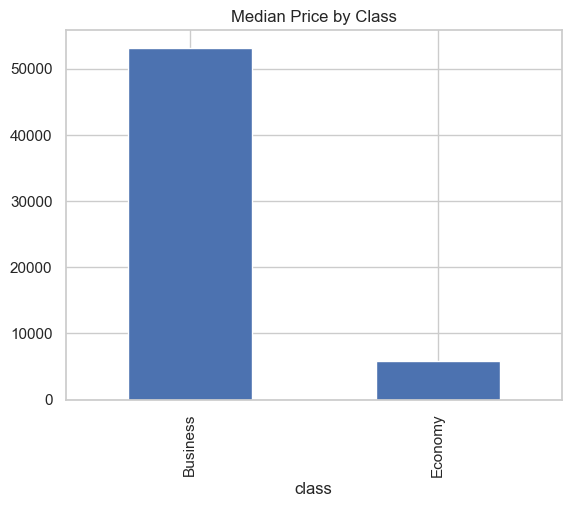

In [48]:
median_class = df.groupby('class')['price'].median()

median_class.plot(kind='bar')
plt.title("Median Price by Class")
plt.show()

# interpretation:
The bar chart shows that Business class has a significantly higher median price compared to Economy class.
The median price of Business class is several times greater, indicating a clear pricing gap between the two classes.
Economy class remains much more affordable with a relatively low median price.
Overall, class is a major determinant of ticket price, with Business class being consistently more expensive.

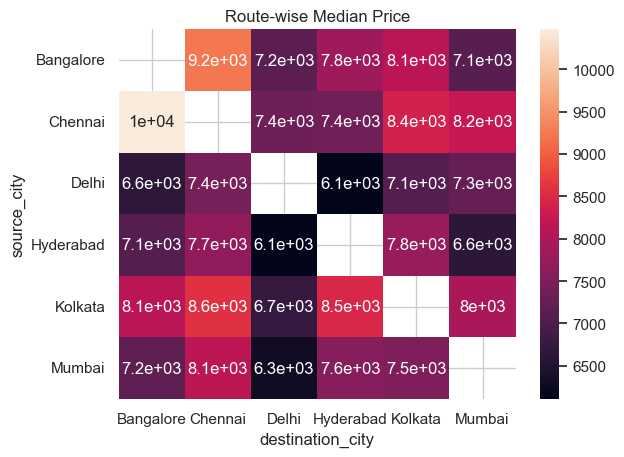

In [49]:
pivot = df.pivot_table(values='price', index='source_city', columns='destination_city', aggfunc='median')

plt.figure()
sns.heatmap(pivot, annot=True)
plt.title("Route-wise Median Price")
plt.show()

# Interpretation:
The heatmap shows that median ticket prices vary across different city routes.
Routes like Chennai → Bangalore and Bangalore → Chennai have higher median prices, indicating higher cost or demand.
Routes such as Delhi → Hyderabad and Mumbai → Delhi have comparatively lower median prices.
Overall, inter-city routes between major metros show noticeable price differences, suggesting that route selection significantly affects ticket pricing.

# Krushkal wallis test

# Assumption
1.Independence of Observations

2.Ordinal or Continuous Dependent Variable

3.Independent Groups (Categorical Independent Variable)

4.Similar Shape of Distributions Across Groups

5.Random Sampling

# H₀ (Null Hypothesis):
There is no significant difference in Median ticket prices across different airlines.
# H₁ (Alternative Hypothesis):
There is a significant difference in Median ticket prices across airlines.

In [50]:
import scipy.stats as stats

# Group data by airline
groups = [grp['price'].values for name, grp in df.groupby('airline')]

# Perform Kruskal-Wallis test
H_stat, p_value = stats.kruskal(*groups)

print("H-statistic:", H_stat)
print("p-value:", p_value)


H-statistic: 94612.80508823584
p-value: 0.0


In [51]:
# Median price for each airline
median_prices = df.groupby('airline')['price'].median()

print("\nMedian Ticket Prices by Airline:")
print(median_prices.sort_values(ascending=False))


Median Ticket Prices by Airline:
airline
Vistara      15543.0
Air_India    11520.0
SpiceJet      5654.0
GO_FIRST      5336.0
Indigo        4453.0
AirAsia       3276.0
Name: price, dtype: float64


# interpretation:
The Kruskal-Wallis test was conducted to examine whether there is a significant difference in median ticket prices across different airlines.

The test results show that the H-statistic is 94612.81 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in median ticket prices among different airlines. In other words, ticket prices vary significantly depending on the airline.

Further analysis of median prices shows that Vistara has the highest median ticket price, followed by Air India, while airlines like Indigo and AirAsia have comparatively lower median prices. This suggests that premium airlines tend to charge higher fares, whereas low-cost carriers offer more affordable pricing.

# H₀:
There is no significant difference in Median ticket prices across different routes.
# H₁:
There is a significant difference in Median ticket prices across routes.

In [52]:
import pandas as pd
import scipy.stats as stats

# Group data by route
grouped = df.groupby('route')

# Extract price values for each route
groups = [grp['price'].values for name, grp in grouped]

# Perform Kruskal-Wallis Test
H_stat, p_value = stats.kruskal(*groups)

# Median price comparison
median_prices = grouped['price'].median().sort_values(ascending=False)

# Print results
print("===== Kruskal-Wallis Test (Route) =====")
print("H-statistic:", H_stat)
print("p-value:", p_value)

print("\n===== Median Price by Route =====")
print(median_prices)

===== Kruskal-Wallis Test (Route) =====
H-statistic: 5047.898801083716
p-value: 0.0

===== Median Price by Route =====
route
Chennai → Bangalore      10469.0
Bangalore → Chennai       9241.0
Kolkata → Chennai         8589.0
Kolkata → Hyderabad       8467.0
Chennai → Kolkata         8394.0
Chennai → Mumbai          8233.0
Mumbai → Chennai          8148.0
Bangalore → Kolkata       8112.0
Kolkata → Bangalore       8111.0
Kolkata → Mumbai          7958.0
Bangalore → Hyderabad     7813.0
Hyderabad → Kolkata       7767.0
Hyderabad → Chennai       7702.0
Mumbai → Hyderabad        7584.0
Mumbai → Kolkata          7518.0
Delhi → Chennai           7425.0
Chennai → Hyderabad       7373.0
Chennai → Delhi           7352.0
Delhi → Mumbai            7262.0
Mumbai → Bangalore        7192.0
Bangalore → Delhi         7164.0
Bangalore → Mumbai        7113.0
Hyderabad → Bangalore     7091.0
Delhi → Kolkata           7084.0
Kolkata → Delhi           6723.0
Delhi → Bangalore         6642.0
Hyderabad → Mumba

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\971275507.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


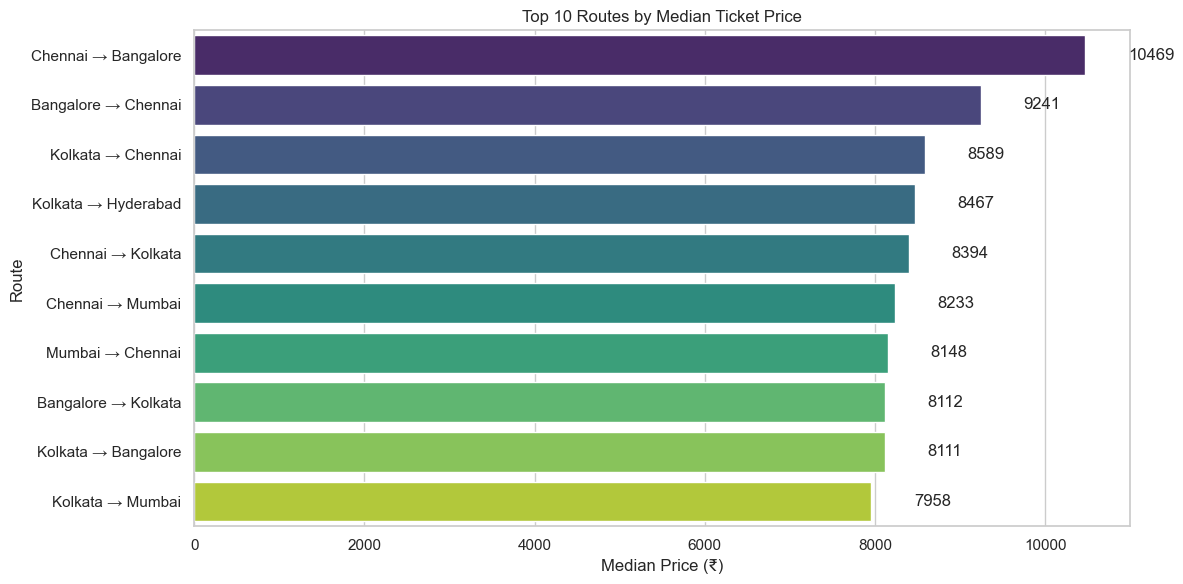

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Create route column (if not already created)
df['route'] = df['source_city'] + " → " + df['destination_city']

# 🔹 Calculate median price for each route
route_median = df.groupby('route')['price'].median()

# 🔹 Get top 10 routes by median price
top_routes_median = route_median.sort_values(ascending=False).head(10)

# 🔹 Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_routes_median.values,
    y=top_routes_median.index,
    palette='viridis'
)

# 🔹 Add values on bars
for i, v in enumerate(top_routes_median.values):
    plt.text(v + 500, i, f"{int(v)}", va='center')

plt.title("Top 10 Routes by Median Ticket Price")
plt.xlabel("Median Price (₹)")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

# Interpretation
The Kruskal-Wallis test was conducted to determine whether there is a significant difference in median ticket prices across different routes.

The results show that the H-statistic is 5047.90 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in ticket prices across different routes. In other words, the route of travel plays an important role in determining ticket prices.

The median price comparison shows that routes such as Chennai → Bangalore (₹10469) and Bangalore → Chennai (₹9241) have higher median prices, while routes like Delhi → Hyderabad (₹6109) and Hyderabad → Delhi (₹6138) have comparatively lower prices. This variation may be due to differences in demand, distance, and route popularity.


# Mann–Whitney U Test (Economy vs Business)

# Hypothesis
# H₀ (Null Hypothesis):There is no significant difference in ticket prices between Economy and Business class.

# H₁ (Alternative Hypothesis):There is a significant difference in ticket prices between Economy and Business class. 

In [54]:
# Step 1: Import libraries
import pandas as pd
import scipy.stats as stats

# Step 2: Handle missing values
df = df.dropna(subset=['class', 'price'])

# Step 3: Create two groups
# Economy class
economy = df[df['class'] == 'Economy']['price']

# Business class
business = df[df['class'] == 'Business']['price']

# Step 4: Perform Mann-Whitney U Test
U_stat, p_value = stats.mannwhitneyu(economy, business, alternative='two-sided')

# Step 5: Median comparison
median_economy = economy.median()
median_business = business.median()

# Step 6: Summary table
summary = pd.DataFrame({
    'Class': ['Economy', 'Business'],
    'Median Price': [median_economy, median_business],
    'Mean Price': [economy.mean(), business.mean()],
    'Count': [economy.count(), business.count()]
})

# Step 7: Print results
print("===== Mann-Whitney U Test (Economy vs Business) =====")
print("U-statistic:", U_stat)
print("p-value:", p_value)

print("\n===== Median Comparison =====")
print("Economy Median:", median_economy)
print("Business Median:", median_business)

print("\n===== Summary Table =====")
print(summary)

===== Mann-Whitney U Test (Economy vs Business) =====
U-statistic: 6234631.5
p-value: 0.0

===== Median Comparison =====
Economy Median: 5772.0
Business Median: 53164.0

===== Summary Table =====
      Class  Median Price    Mean Price   Count
0   Economy        5772.0   6572.342383  206666
1  Business       53164.0  52540.081124   93487


# interpretation:
The Mann–Whitney U test was conducted to determine whether there is a significant difference in ticket prices between Economy and Business class flights.

The results show that the U-statistic is 6,234,631.5 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in ticket prices between Economy and Business class. In other words, the class of travel has a strong and significant impact on airline ticket pricing.

The median price comparison clearly shows that Business class has a much higher median price (₹53,164) compared to Economy class (₹5,772). This substantial difference highlights the premium nature of Business class, which offers enhanced services such as greater comfort, additional amenities, and priority services.

Furthermore, the mean prices also support this observation, with Business class (₹52,540) being significantly higher than Economy class (₹6,572). The large difference in both median and mean values confirms that ticket prices are heavily influenced by travel class.


# obj_3

# Spearmen  correlation

In [55]:
# Step 1: Import required libraries
import pandas as pd
import scipy.stats as stats

# Step 2: Check basic info (optional but recommended)
print(df[['duration', 'days_left', 'price']].describe())

# Step 3: Handle missing values (important)
df = df.dropna(subset=['duration', 'days_left', 'price'])

# Step 4: Spearman Correlation (Duration vs Price)
corr_duration, p_duration = stats.spearmanr(df['duration'], df['price'])

# Step 5: Spearman Correlation (Days Left vs Price)
corr_days, p_days = stats.spearmanr(df['days_left'], df['price'])

# Step 6: Print results
print("===== Spearman Correlation Results =====")

print("\nDuration vs Price:")
print("Correlation coefficient:", corr_duration)
print("p-value:", p_duration)

print("\nDays Left vs Price:")
print("Correlation coefficient:", corr_days)
print("p-value:", p_days)

            duration      days_left          price
count  300153.000000  300153.000000  300153.000000
mean      733.259055      26.004751   20889.660523
std       431.518381      13.561004   22697.767366
min        50.000000       1.000000    1105.000000
25%       410.000000      15.000000    4783.000000
50%       675.000000      26.000000    7425.000000
75%       970.000000      38.000000   42521.000000
max      2990.000000      49.000000  123071.000000
===== Spearman Correlation Results =====

Duration vs Price:
Correlation coefficient: 0.31884122663345993
p-value: 0.0

Days Left vs Price:
Correlation coefficient: -0.26701898446039224
p-value: 0.0


In [56]:
# Create summary table
results = pd.DataFrame({
    'Variable': ['Duration vs Price', 'Days Left vs Price'],
    'Correlation (Spearman)': [corr_duration, corr_days],
    'p-value': [p_duration, p_days]
})

print(results)

             Variable  Correlation (Spearman)  p-value
0   Duration vs Price                0.318841      0.0
1  Days Left vs Price               -0.267019      0.0


# interpretation 
Spearman correlation analysis was conducted to examine the relationship between duration, days left before departure, and ticket price.

The results show that the correlation between duration and price is 0.3188, with a p-value of 0.0, indicating a moderate positive relationship that is statistically significant. This means that as the duration of the flight increases, the ticket price tends to increase as well. Longer flights generally cost more due to higher operational costs and distance.

On the other hand, the correlation between days left and price is -0.2670, with a p-value of 0.0, indicating a moderate negative relationship that is also statistically significant. This suggests that as the number of days left before departure increases, the ticket price tends to decrease. In other words, booking tickets earlier usually results in lower prices, while last-minute bookings are more expensive.

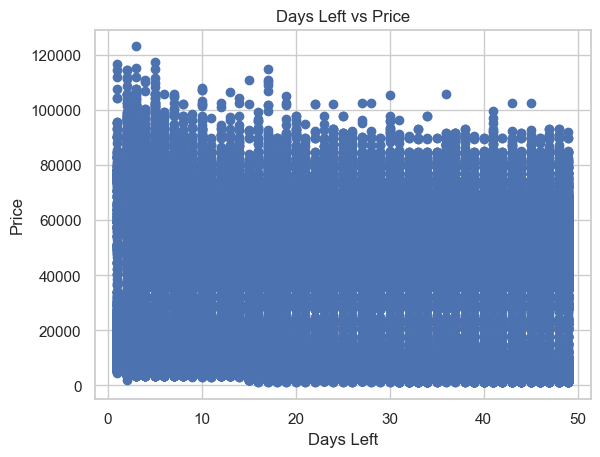

In [57]:
plt.figure()
plt.scatter(df['days_left'], df['price'])
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.title("Days Left vs Price")
plt.show()

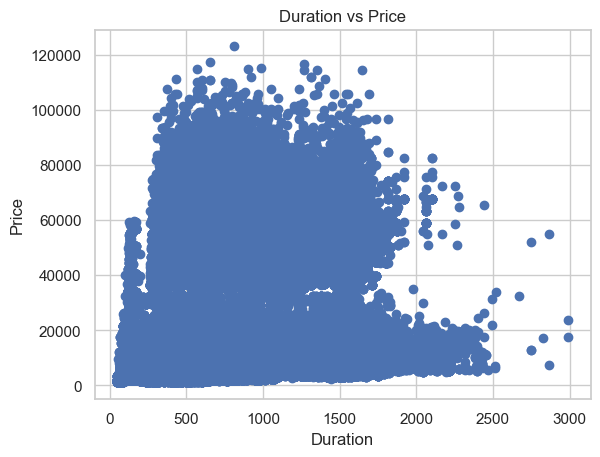

In [58]:
plt.figure()
plt.scatter(df['duration'], df['price'])
plt.xlabel("Duration")
plt.ylabel("Price")
plt.title("Duration vs Price")
plt.show()

# Boxplot

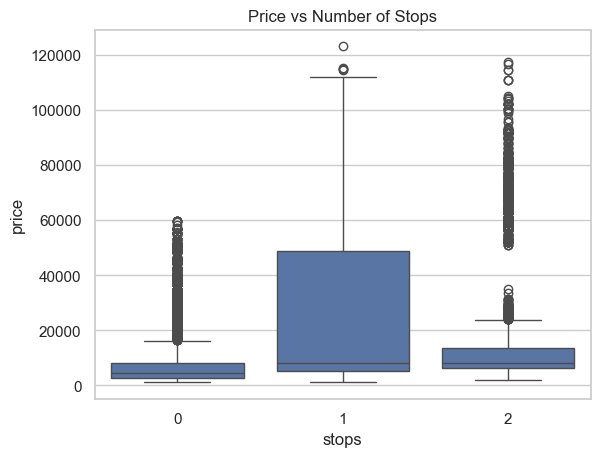

In [59]:
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price vs Number of Stops")
plt.show()

# Interpretation:
The boxplot shows that flights with 1 stop have the highest median price and the greatest variability, indicating they are often more expensive.
Non-stop flights (0 stops) generally have lower prices, though some high-value outliers are present.
Flights with 2 stops show moderate prices but include several high-price outliers.
Overall, price does not increase linearly with stops, but 1-stop flights tend to be the most costly on average.

# Krushkal wallis 

# H₀ (Null Hypothesis):
There is no significant difference in ticket prices across different numbers of stops.

# H₁ (Alternative Hypothesis):
There is a significant difference in ticket prices across different numbers of stops.

In [60]:
# Step 1: Import libraries
import pandas as pd
import scipy.stats as stats

# Step 2: Handle missing values (important)
df = df.dropna(subset=['stops', 'price'])

# Step 3: Group data by number of stops
grouped = df.groupby('stops')

# Step 4: Extract price values for each group
groups = [grp['price'].values for name, grp in grouped]

# Step 5: Perform Kruskal-Wallis Test
H_stat, p_value = stats.kruskal(*groups)

# Step 6: Median price comparison
median_prices = grouped['price'].median().sort_values(ascending=False)

# Step 7: Detailed summary (recommended for report)
summary = grouped['price'].agg(['median', 'mean', 'count']).sort_values(by='median', ascending=False)

# Step 8: Print results
print("===== Kruskal-Wallis Test (Stops) =====")
print("H-statistic:", H_stat)
print("p-value:", p_value)

print("\n===== Median Price by Stops =====")
print(median_prices)

print("\n===== Detailed Summary =====")
print(summary)

===== Kruskal-Wallis Test (Stops) =====
H-statistic: 20484.29943114362
p-value: 0.0

===== Median Price by Stops =====
stops
2    8307.0
1    7959.0
0    4499.0
Name: price, dtype: float64

===== Detailed Summary =====
       median          mean   count
stops                              
2      8307.0  14113.450775   13286
1      7959.0  22900.992482  250863
0      4499.0   9375.938535   36004


# Interpretation
The Kruskal-Wallis test was conducted to examine whether there is a significant difference in median ticket prices across different numbers of stops.

The test results show that the H-statistic is 20484.30 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in ticket prices based on the number of stops. In other words, the number of stops has a significant impact on airline ticket pricing.

The median price comparison reveals that flights with 2 stops have the highest median price (₹8307), followed by 1 stop (₹7959), while non-stop flights have the lowest median price (₹4499). This suggests that ticket prices vary across stop categories, possibly due to route complexity, distance, or airline pricing strategies.

# Mann–Whitney U Test (0 stops vs >0 stops)

# Assumption 


# H₀ (Null Hypothesis):
There is no significant difference in ticket prices between non-stop flights (0 stops) and flights with stops (>0).

# H₁ (Alternative Hypothesis):
There is a significant difference in ticket prices between these two groups

In [61]:
# Step 1: Import libraries
import pandas as pd
import scipy.stats as stats

# Step 2: Handle missing values
df = df.dropna(subset=['stops', 'price'])

# Step 3: Create two groups
# Group 1: Non-stop flights (0 stops)
group1 = df[df['stops'] == 0]['price']

# Group 2: Flights with stops (>0)
group2 = df[df['stops'] > 0]['price']

# Step 4: Perform Mann-Whitney U Test
U_stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')

# Step 5: Median comparison
median_0 = group1.median()
median_more = group2.median()

# Step 6: Summary table
summary = pd.DataFrame({
    'Group': ['0 Stops (Non-stop)', '>0 Stops'],
    'Median Price': [median_0, median_more],
    'Mean Price': [group1.mean(), group2.mean()],
    'Count': [group1.count(), group2.count()]
})

# Step 7: Print results
print("===== Mann-Whitney U Test (0 stops vs >0 stops) =====")
print("U-statistic:", U_stat)
print("p-value:", p_value)

print("\n===== Median Comparison =====")
print("0 Stops Median:", median_0)
print(">0 Stops Median:", median_more)

print("\n===== Summary Table =====")
print(summary)

===== Mann-Whitney U Test (0 stops vs >0 stops) =====
U-statistic: 2549488655.5
p-value: 0.0

===== Median Comparison =====
0 Stops Median: 4499.0
>0 Stops Median: 8016.0

===== Summary Table =====
                Group  Median Price    Mean Price   Count
0  0 Stops (Non-stop)        4499.0   9375.938535   36004
1            >0 Stops        8016.0  22459.002245  264149


# interpretation
The Mann–Whitney U test was conducted to determine whether there is a significant difference in ticket prices between non-stop flights (0 stops) and flights with stops (>0 stops).

The test results show that the U-statistic is 254,948,665.5 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in ticket prices between the two groups. In other words, the number of stops significantly affects ticket pricing.

The median price comparison shows that flights with stops (>0 stops) have a higher median price (₹8016) compared to non-stop flights (₹4499). This suggests that, in this dataset, flights with stops are relatively more expensive than direct flights.

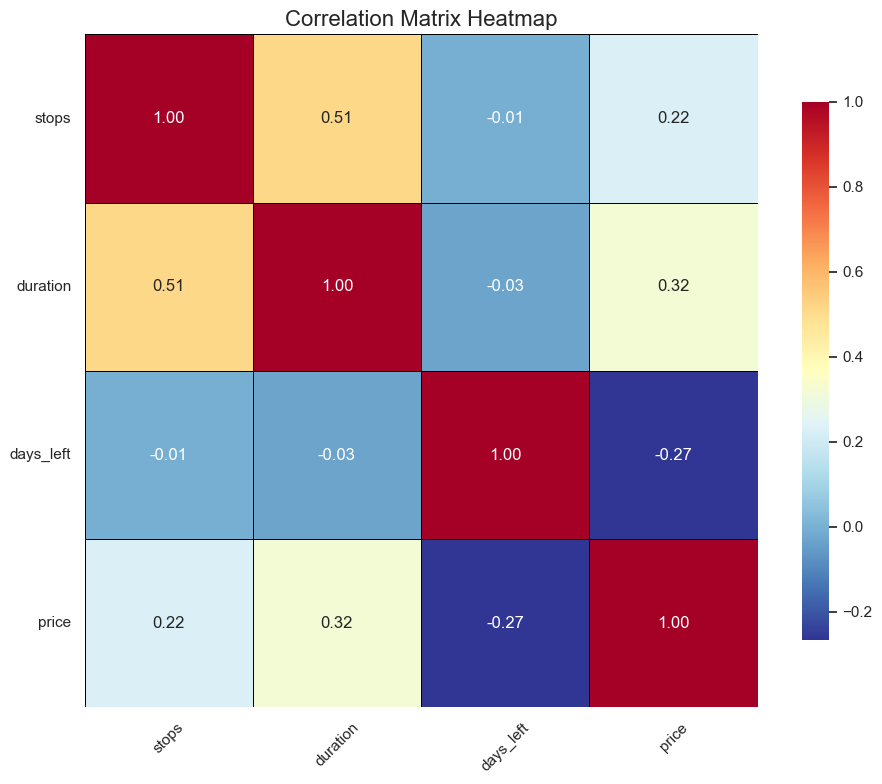

In [62]:
# ==============================
# Step 2: Select Numeric Columns
# ==============================
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# ==============================
# Step 3: Compute Correlation Matrix
# ==============================
corr = numeric_df.corr(method='spearman')  # better for your data

# ==============================
# Step 4: Plot Colorful Heatmap
# ==============================
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",   # 🔥 colorful (red-yellow-blue)
    linewidths=0.5,
    linecolor='black',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Interpretation
The correlation heatmap shows the relationship between key variables: stops, duration, days_left, and price using Spearman correlation.

The results indicate that duration has a moderate positive correlation with price (0.32), meaning that as the duration of the flight increases, the ticket price tends to increase. Similarly, stops also show a positive relationship with price (0.22), suggesting that flights with more stops are slightly more expensive in this dataset.

On the other hand, days_left has a negative correlation with price (-0.27), indicating that ticket prices decrease as the number of days left before departure increases. This confirms that early booking leads to lower ticket prices, while last-minute bookings are more expensive.

Additionally, there is a moderate positive correlation between stops and duration (0.51), which implies that flights with more stops generally have longer travel durations.

# Obj-4

In [63]:
df['booking_group'] = pd.cut(df['days_left'],
                            bins=[0, 5, 15, 30, 60, 365],
                            labels=['0-5', '6-15', '16-30', '31-60', '60+'])

# meadian Bar chart  of booking group

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\2771390276.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_booking = df.groupby('booking_group')['price'].median()
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\2771390276.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_booking = df.groupby('booking_group')['price'].count()
posx and posy should be finite values
posx and posy should be finite values


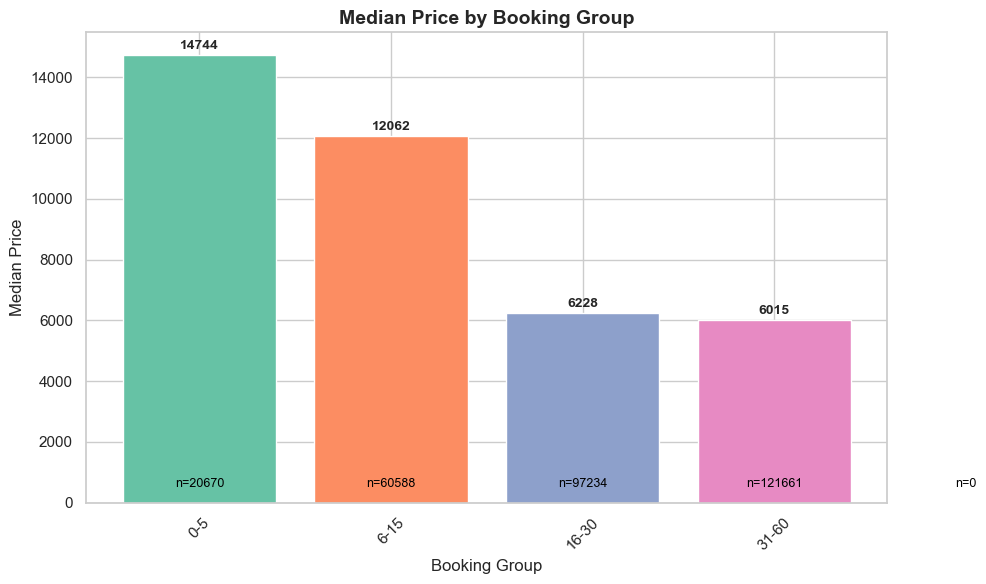

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate median and count
median_booking = df.groupby('booking_group')['price'].median()
count_booking = df.groupby('booking_group')['price'].count()

# Reset index for plotting
plot_df = median_booking.reset_index()
plot_df.columns = ['booking_group', 'median_price']
plot_df['count'] = count_booking.values

# Set style
sns.set(style="whitegrid")

# Create colorful bar chart
plt.figure(figsize=(10,6))
colors = sns.color_palette("Set2", len(plot_df))

bars = plt.bar(plot_df['booking_group'], plot_df['median_price'], color=colors)

# Add labels on bars (median price)
for bar, price in zip(bars, plot_df['median_price']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{price:.0f}', ha='center', fontsize=10, fontweight='bold')

# Add count labels below bars
for bar, count in zip(bars, plot_df['count']):
    plt.text(bar.get_x() + bar.get_width()/2, 500,
             f'n={count}', ha='center', fontsize=9, color='black')

# Titles and labels
plt.title('Median Price by Booking Group', fontsize=14, fontweight='bold')
plt.xlabel('Booking Group', fontsize=12)
plt.ylabel('Median Price', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretation
The chart shows that ticket prices are highest when booking 0–5 days before departure, indicating last-minute bookings are most expensive.
Prices gradually decrease as the booking window increases, with 16–60 days having much lower median prices.
This suggests a clear trend that early booking leads to cheaper tickets.
The 60+ group has no values (NaN), indicating insufficient or missing data for that category.

# Days Left vs Price

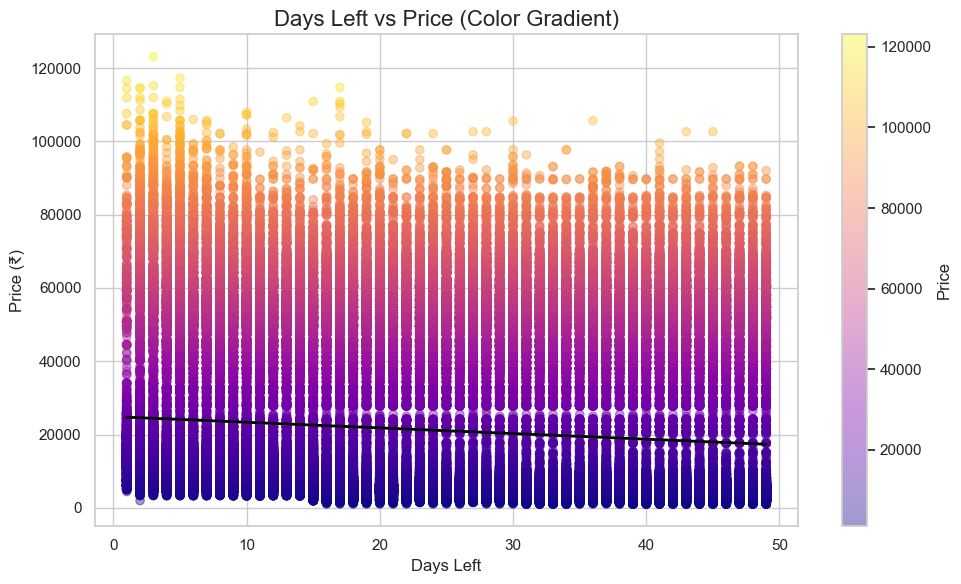

In [65]:
import numpy as np

plt.figure(figsize=(10,6))

# Scatter for gradient effect
plt.scatter(
    df['days_left'],
    df['price'],
    c=df['price'],
    cmap='plasma',
    alpha=0.4
)

# Smooth trend line
sns.regplot(
    data=df,
    x='days_left',
    y='price',
    scatter=False,
    color='black',
    line_kws={'linewidth':2}
)

plt.title("Days Left vs Price (Color Gradient)", fontsize=16)
plt.xlabel("Days Left")
plt.ylabel("Price (₹)")
plt.colorbar(label='Price')

plt.tight_layout()
plt.show()

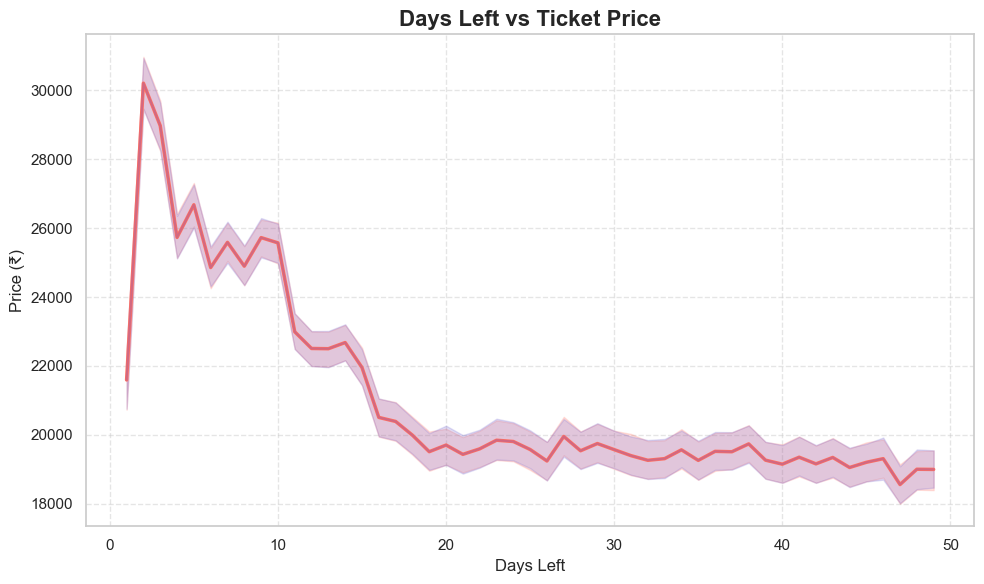

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Plot with colorful palette
sns.lineplot(
    data=df,
    x='days_left',
    y='price',
    color='#ff6f61',        # main line color
    linewidth=2.5
)

# Add smooth confidence band (optional)
sns.lineplot(
    data=df,
    x='days_left',
    y='price',
    color='#6a5acd',        # second overlay color
    alpha=0.3
)

# Titles and labels
plt.title("Days Left vs Ticket Price", fontsize=16, fontweight='bold')
plt.xlabel("Days Left", fontsize=12)
plt.ylabel("Price (₹)", fontsize=12)

# Grid styling
plt.grid(True, linestyle='--', alpha=0.5)

# Show plot
plt.tight_layout()
plt.show()

# Median Price by Departure time

departure_time
Afternoon        6663.0
Early_Morning    7212.0
Evening          7425.0
Late_Night       4499.0
Morning          8112.0
Night            7813.0
Name: price, dtype: float64


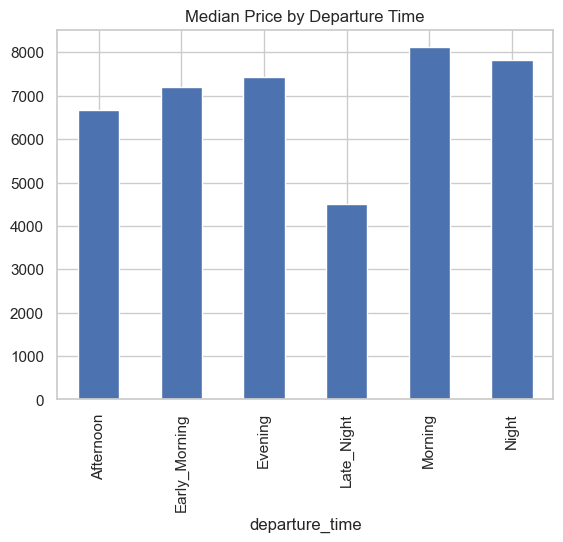

In [67]:
median_dep = df.groupby('departure_time')['price'].median()
print(median_dep)

median_dep.plot(kind='bar')
plt.title("Median Price by Departure Time")
plt.show()

# Interpretation
The chart shows that Morning flights have the highest median price, followed by Night and Evening flights.
Late Night flights have the lowest median price, making them the most economical option.
Afternoon and Early Morning flights fall in the mid-price range.

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1426147836.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_3720\1426147836.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


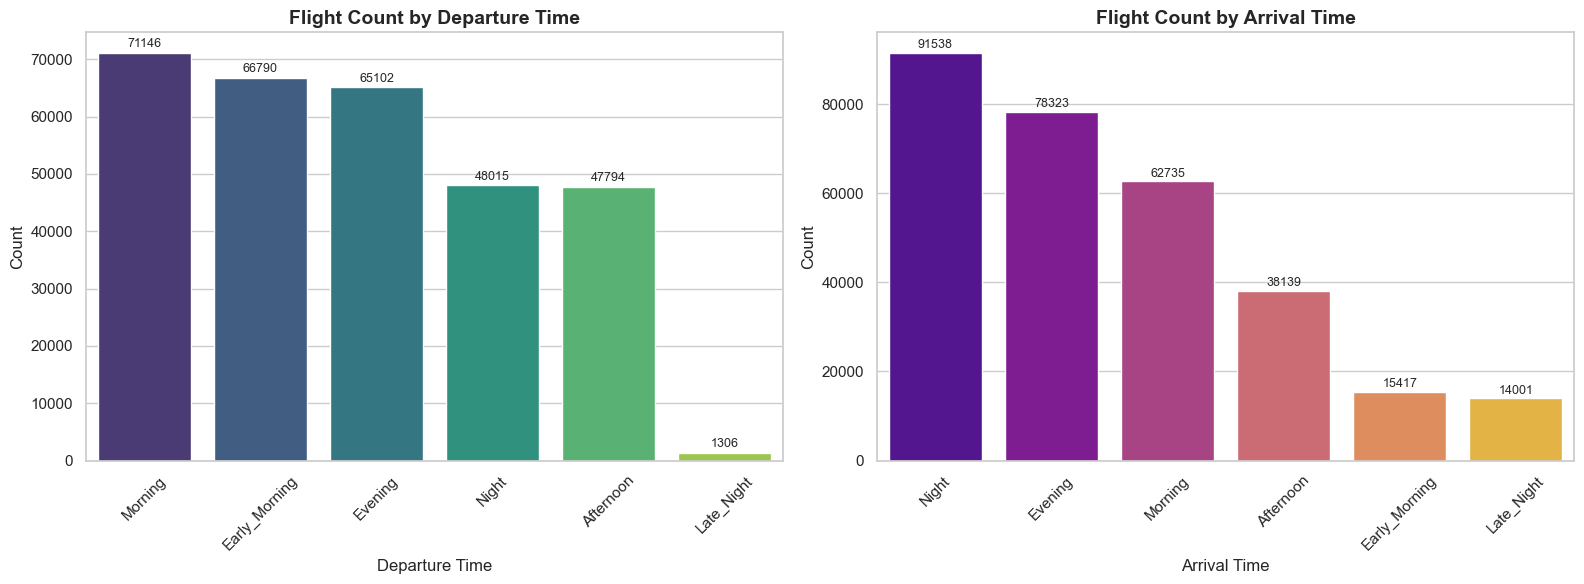

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# 🔹 Count data
dep_counts = df['departure_time'].value_counts().sort_values(ascending=False)
arr_counts = df['arrival_time'].value_counts().sort_values(ascending=False)

# 🔹 Create figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 🎯 Departure Time Chart
sns.barplot(
    x=dep_counts.index,
    y=dep_counts.values,
    palette='viridis',
    ax=axes[0]
)

axes[0].set_title("Flight Count by Departure Time", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Departure Time")
axes[0].set_ylabel("Count")

# Add values
for i, v in enumerate(dep_counts.values):
    axes[0].text(i, v + 1000, str(v), ha='center', fontsize=9)

axes[0].tick_params(axis='x', rotation=45)

# 🎯 Arrival Time Chart
sns.barplot(
    x=arr_counts.index,
    y=arr_counts.values,
    palette='plasma',
    ax=axes[1]
)

axes[1].set_title("Flight Count by Arrival Time", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Arrival Time")
axes[1].set_ylabel("Count")

# Add values
for i, v in enumerate(arr_counts.values):
    axes[1].text(i, v + 1000, str(v), ha='center', fontsize=9)

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Boxplot by Departure time

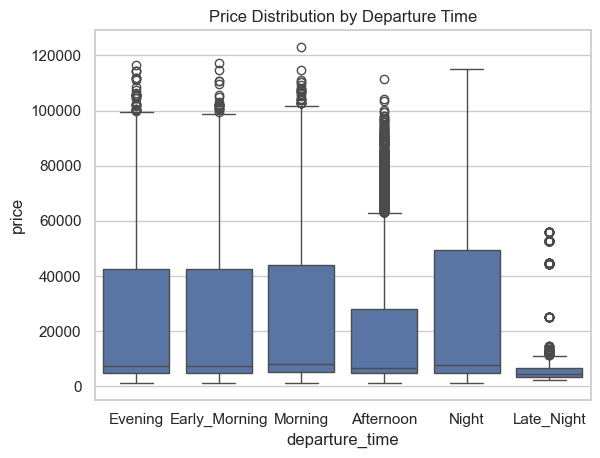

In [69]:
sns.boxplot(x='departure_time', y='price', data=df)
plt.title("Price Distribution by Departure Time")
plt.show()

# Interpretation 
The boxplot shows that Morning and Night flights have higher median prices and wider variability, indicating they are generally more expensive.
Late Night and Afternoon flights have lower median prices, making them more economical options.
All time slots contain several high-price outliers, especially in Morning and Evening flights.
Overall, departure time influences ticket pricing, but the wide spread suggests other factors also affect price.

# Krushkal wallis test

# Hypothesis

# H₀ (Null Hypothesis):
There is no significant difference in ticket prices across different departure times.

# H₁ (Alternative Hypothesis):
There is a significant difference in ticket prices across different departure times.

In [70]:
# Step 1: Import libraries
import pandas as pd
import scipy.stats as stats

# Step 2: Handle missing values
df = df.dropna(subset=['departure_time', 'price'])

# Step 3: Group data by departure time
grouped = df.groupby('departure_time')

# Step 4: Extract price values for each group
groups = [grp['price'].values for name, grp in grouped]

# Step 5: Perform Kruskal-Wallis Test
H_stat, p_value = stats.kruskal(*groups)

# Step 6: Median price comparison
median_prices = grouped['price'].median().sort_values(ascending=False)

# Step 7: Detailed summary (for report)
summary = grouped['price'].agg(['median', 'mean', 'count']).sort_values(by='median', ascending=False)

# Step 8: Print results
print("===== Kruskal-Wallis Test (Departure Time) =====")
print("H-statistic:", H_stat)
print("p-value:", p_value)

print("\n===== Median Price by Departure Time =====")
print(median_prices)

print("\n===== Detailed Summary =====")
print(summary)

===== Kruskal-Wallis Test (Departure Time) =====
H-statistic: 1873.4313310335824
p-value: 0.0

===== Median Price by Departure Time =====
departure_time
Morning          8112.0
Night            7813.0
Evening          7425.0
Early_Morning    7212.0
Afternoon        6663.0
Late_Night       4499.0
Name: price, dtype: float64

===== Detailed Summary =====
                median          mean  count
departure_time                             
Morning         8112.0  21630.760254  71146
Night           7813.0  23062.146808  48015
Evening         7425.0  21232.361894  65102
Early_Morning   7212.0  20370.676718  66790
Afternoon       6663.0  18179.203331  47794
Late_Night      4499.0   9295.299387   1306


# Interpretation
The Kruskal-Wallis test was conducted to determine whether there is a significant difference in ticket prices across different departure times.

The results show that the H-statistic is 1873.43 and the p-value is 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

This indicates that there is a statistically significant difference in ticket prices based on departure time. In other words, the time of departure plays an important role in determining airline ticket prices.

The median price comparison reveals that morning flights have the highest median price (₹8112), followed by night (₹7813) and evening flights (₹7425), while late night flights have the lowest median price (₹4499). This suggests that flights during more convenient and high-demand time periods (such as morning and evening) tend to be more expensive, whereas less preferred times like late night are relatively cheaper.

# Obj-5

# Quantile Regression¶

# Assumption 
1.Linearity in Parameters

2.Independence of Observations

3.No Perfect Multicollinearity

4.Correct Model Specification

5.Existence of Conditional Quantiles

6.Large Sample Size (for stability)

7.No Quantile Crossing (practical condition)

In [71]:
df = df.drop(['booking_group', 'route'], axis=1, errors='ignore')

In [72]:
df = df.drop('flight', axis=1, errors='ignore')

# VIF Check

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Add constant
X_const = sm.add_constant(X)

# Convert to float (IMPORTANT FIX)
X_const = X_const.astype(float)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

print(vif_data)

            Feature        VIF
0             const  28.656652
1           airline   1.040879
2       source_city   1.055431
3    departure_time   1.020381
4             stops   1.296848
5      arrival_time   1.007228
6  destination_city   1.055160
7             class   1.061483
8          duration   1.331810
9         days_left   1.001875


In [74]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [75]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [76]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [77]:
X = sm.add_constant(X)

In [79]:
# 25th percentile (low price)
model_25 = sm.QuantReg(y, X).fit(q=0.25)

# 50th percentile (median)
model_50 = sm.QuantReg(y, X).fit(q=0.5)

# 75th percentile (high price)
model_75 = sm.QuantReg(y, X).fit(q=0.75)

In [80]:
print("----- 25th Quantile -----")
print(model_25.summary())

print("----- 50th Quantile -----")
print(model_50.summary())

print("----- 75th Quantile -----")
print(model_75.summary())

----- 25th Quantile -----
                         QuantReg Regression Results                          
Dep. Variable:                  price   Pseudo R-squared:               0.6047
Model:                       QuantReg   Bandwidth:                       263.7
Method:                 Least Squares   Sparsity:                        7687.
Date:                Thu, 02 Apr 2026   No. Observations:               300153
Time:                        17:02:25   Df Residuals:                   300143
                                        Df Model:                            9
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4.192e+04     34.881   1201.847      0.000    4.19e+04     4.2e+04
airline            413.7858      3.484    118.779      0.000     406.958     420.614
source_city        131.8548      3.572     36.912      0.000     124.853     138.

In [81]:
coef_df = pd.DataFrame({
    '25th': model_25.params,
    '50th': model_50.params,
    '75th': model_75.params
})

print(coef_df)

                          25th          50th          75th
const             41922.066279  50765.726193  57429.404387
airline             413.785817    516.587788    575.752455
source_city         131.854830     35.834393     54.370429
departure_time       10.482782     17.238839     34.280096
stops              2239.330185   2312.185466   2775.993544
arrival_time         35.355306     52.735569     57.032912
destination_city    142.394673     52.365432     69.460099
class            -40034.906239 -46497.059613 -51176.359029
duration              1.230125      1.157698      1.041907
days_left           -81.471251   -113.513113   -146.986320


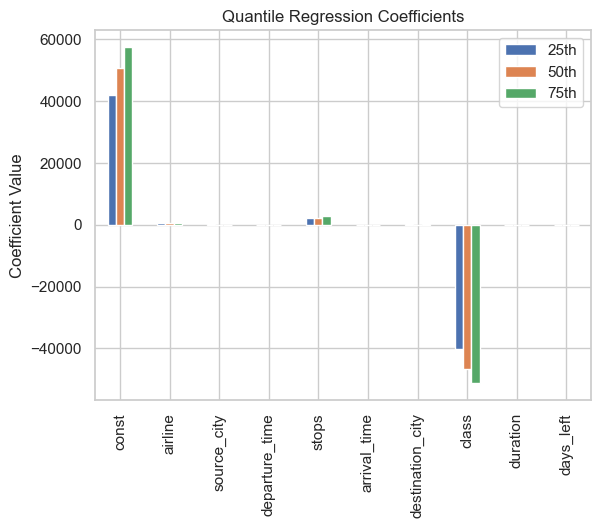

In [82]:
coef_df.plot(kind='bar')
plt.title("Quantile Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

In [83]:
y_pred = model_50.predict(X)

In [84]:
print("Pseudo R² (Median):", model_50.prsquared)

Pseudo R² (Median): 0.737298898121596


In [85]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y, y_pred))

MAE: 4242.146999076945


In [86]:
pred_25 = model_25.predict(X)
pred_50 = model_50.predict(X)
pred_75 = model_75.predict(X)

print((pred_25 <= pred_50).all())
print((pred_50 <= pred_75).all())

True
True


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_50 = sm.QuantReg(y_train, X_train).fit(q=0.5)

y_pred = model_50.predict(X_test)

In [88]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)

Test MAE: 4221.25171369128


In [89]:
pred_25 = np.minimum(pred_25, pred_50)
pred_75 = np.maximum(pred_75, pred_50)

In [90]:
pred_25

0          4794.173388
1          4760.636547
2          2987.126112
3          5058.298863
4          5205.870711
              ...     
300148    43654.140272
300149    43742.877555
300150    44005.535895
300151    43616.541302
300152    43654.140272
Length: 300153, dtype: float64

In [91]:
pred_50

0          7003.656825
1          6945.259398
2          4709.124559
3          7296.832935
4          7513.563701
              ...     
300148    51166.472508
300149    51278.877820
300150    51533.444743
300151    51108.967502
300152    51166.472508
Length: 300153, dtype: float64

In [92]:
pred_75

0          9354.282817
1          9273.388875
2          6788.861254
3          9718.640439
4          9951.981618
              ...     
300148    57026.120937
300149    57080.937419
300150    57328.808362
300151    56918.071116
300152    57026.120937
Length: 300153, dtype: float64

In [93]:
residuals = y_test - y_pred

In [94]:
residuals

27131      3033.583944
266857    12477.585274
141228      479.864658
288329     4627.870368
97334       650.970377
              ...     
5234       -340.012030
5591       -311.709710
168314     1498.177675
175191     3204.642349
287693     8880.623907
Length: 60031, dtype: float64

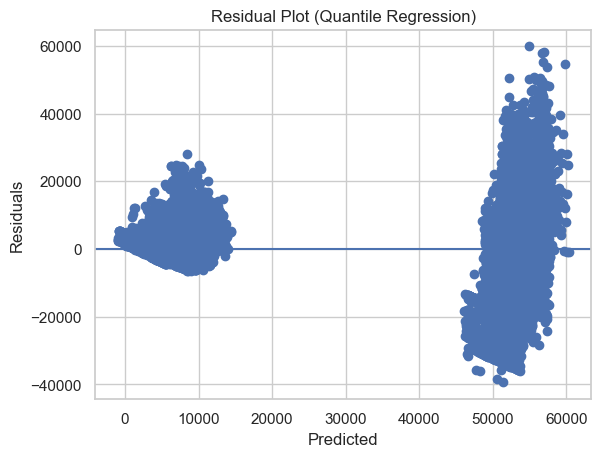

In [95]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Quantile Regression)")
plt.show()

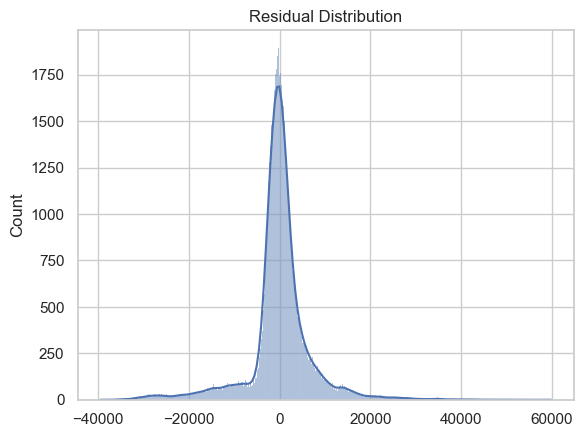

In [96]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

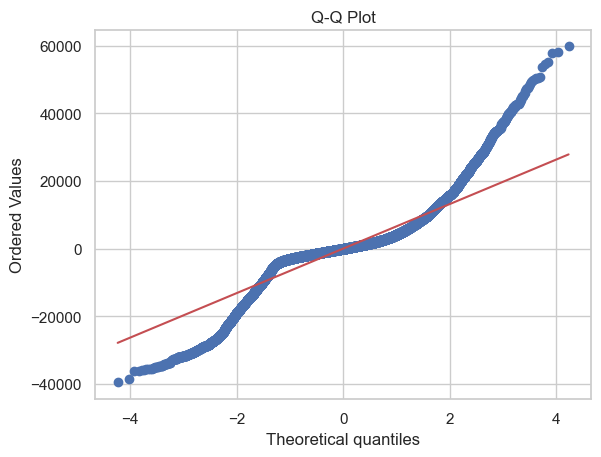

In [97]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [98]:
print("Mean Residual:", residuals.mean())

Mean Residual: 54.87956803781896


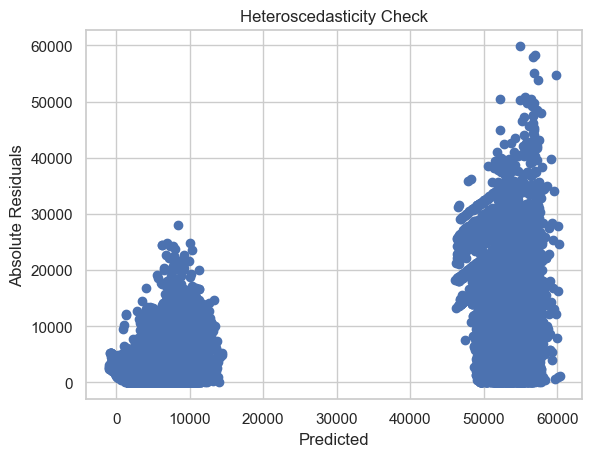

In [99]:
plt.scatter(y_pred, abs(residuals))
plt.xlabel("Predicted")
plt.ylabel("Absolute Residuals")
plt.title("Heteroscedasticity Check")
plt.show()